In [1]:
import sys
sys.path.append('..')
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import colorcet as cc
from scipy import stats

import matplotlib
import matplotlib.font_manager as fm
font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = 'Helvetica'

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

from src.inversion_scripts.utils import plot_field, sum_total_emissions, get_posterior_emissions, get_mean_emissions

In [2]:
state_vector_filepath = "/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2022_annual/StateVector.nc"

state_vector = xr.open_dataset(state_vector_filepath)
state_vector_labels = state_vector["StateVector"]

# Identify the last element of the region of interest
last_ROI_element = int(
    np.nanmax(state_vector_labels.values)
)

# Define mask for region of interest
mask = state_vector_labels <= last_ROI_element

### Check original LPJ wetland emissions in each year

In [3]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
total_emissions_list = []
total_emissions_nhl_list = []
total_emissions_tropics_list = []

for year in years:
    # set directory
    if year == 2019:
        prior_cache = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_burnin/hemco_prior_emis/OutputDir_{year}_inventory'
    else:
        prior_cache = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/hemco_prior_emis/OutputDir_{year}_inventory'

    start_date = f'{year}0101'
    end_date = f'{year+1}0101'

    prior_ds = get_mean_emissions(start_date, end_date, prior_cache)
    prior_wetlands = prior_ds["EmisCH4_Wetlands"]
    # get prior_wetlands in NHL
    prior_wetlands_nhl = prior_wetlands.where(prior_wetlands['lat'] > 50, drop=True)
    # get prior_wetlands in tropics
    prior_wetlands_tropics = prior_wetlands.where((prior_wetlands['lat'] < 10) & (prior_wetlands['lat'] > -10), drop=True)
    areas = prior_ds["AREA"]

    total_prior_wetland_emissions = sum_total_emissions(prior_wetlands, areas, mask)
    total_prior_wetland_emissions_nhl = sum_total_emissions(prior_wetlands_nhl, areas, mask)
    total_prior_wetland_emissions_tropics = sum_total_emissions(prior_wetlands_tropics, areas, mask)

    total_emissions_list.append(total_prior_wetland_emissions)
    total_emissions_nhl_list.append(total_prior_wetland_emissions_nhl)
    total_emissions_tropics_list.append(total_prior_wetland_emissions_tropics)

df = pd.DataFrame({
    'Year': years,
    'Wetland Emissions (Tg)': total_emissions_list,
    'Wetland Emissions NHL (Tg)': total_emissions_nhl_list,
    'Wetland Emissions Tropics (Tg)': total_emissions_tropics_list
})
print(df)

   Year  Wetland Emissions (Tg)  Wetland Emissions NHL (Tg)  \
0  2019              191.055738                   34.113584   
1  2020              199.991215                   41.931776   
2  2021              197.335575                   37.668810   
3  2022              195.102893                   37.663728   
4  2023              186.291574                   38.666099   
5  2024              186.167068                   38.564617   

   Wetland Emissions Tropics (Tg)  
0                       80.171058  
1                       80.584123  
2                       79.804585  
3                       80.202595  
4                       71.905596  
5                       71.918722  


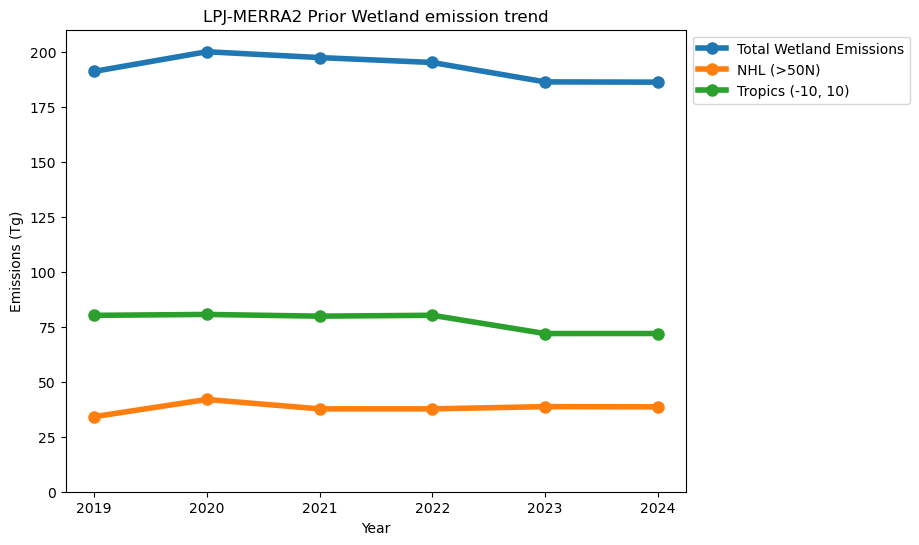

In [4]:
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(df['Year'], df['Wetland Emissions (Tg)'], lw=4, marker='o', markersize=8, label='Total Wetland Emissions')
plt.plot(df['Year'], df['Wetland Emissions NHL (Tg)'], lw=4, marker='o', markersize=8, label='NHL (>50N)')
plt.plot(df['Year'], df['Wetland Emissions Tropics (Tg)'], lw=4, marker='o', markersize=8, label='Tropics (-10, 10)')
plt.xticks(df['Year'])
plt.ylim(0, 210)
plt.xlabel('Year')
plt.ylabel('Emissions (Tg)')
plt.title('LPJ-MERRA2 Prior Wetland emission trend')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### Check posterior wetland emissions

In [5]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
total_emissions_list = []
total_emissions_nhl_list = []
total_emissions_tropics_list = []

for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]
    areas = posterior_ds["AREA"]

    # NHL
    posterior_wetlands_nhl = posterior_wetlands.where(posterior_wetlands['lat'] > 50, drop=True)
    # tropics
    posterior_wetlands_tropics = posterior_wetlands.where((posterior_wetlands['lat'] < 10) & (posterior_wetlands['lat'] > -10), drop=True)
    areas = posterior_ds["AREA"]

    total_posterior_wetland_emissions = sum_total_emissions(posterior_wetlands, areas, mask)
    total_posterior_wetland_emissions_nhl = sum_total_emissions(posterior_wetlands_nhl, areas, mask)
    total_posterior_wetland_emissions_tropics = sum_total_emissions(posterior_wetlands_tropics, areas, mask)

    total_emissions_list.append(total_posterior_wetland_emissions)
    total_emissions_nhl_list.append(total_posterior_wetland_emissions_nhl)
    total_emissions_tropics_list.append(total_posterior_wetland_emissions_tropics)

# append total_emissions_list, total_emissions_nhl_list, total_emissions_tropics_list to df
df['Posterior Wetland Emissions'] = total_emissions_list
df['Posterior NHL'] = total_emissions_nhl_list
df['Posterior Tropics'] = total_emissions_tropics_list


In [6]:
df

,Year,Wetland Emissions (Tg),Wetland Emissions NHL (Tg),Wetland Emissions Tropics (Tg),Posterior Wetland Emissions,Posterior NHL,Posterior Tropics
0,2019,191.055738,34.113584,80.171058,180.443523,32.600807,83.063965
1,2020,199.991215,41.931776,80.584123,175.446889,34.335638,84.623179
2,2021,197.335575,37.668810,79.804585,181.219198,33.077600,82.911630
3,2022,195.102893,37.663728,80.202595,171.275980,33.181657,77.259053
4,2023,186.291574,38.666099,71.905596,160.298945,29.007838,74.390688
5,2024,186.167068,38.564617,71.918722,161.546669,34.368801,67.621669


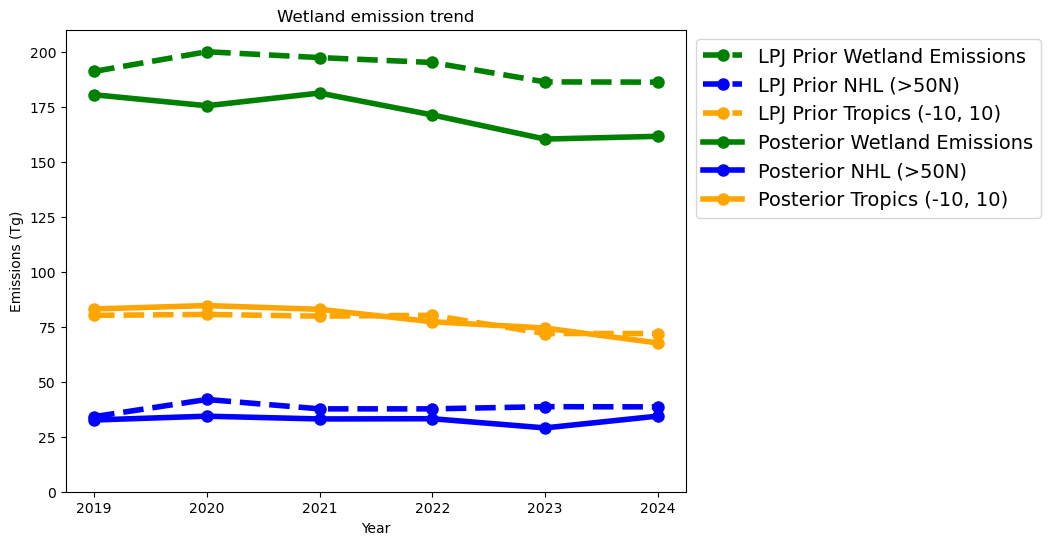

In [7]:
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(df['Year'], df['Wetland Emissions (Tg)'], color='green', lw=4, linestyle='--', marker='o', markersize=8, label='LPJ Prior Wetland Emissions')
plt.plot(df['Year'], df['Wetland Emissions NHL (Tg)'], color='blue', lw=4, linestyle='--', marker='o', markersize=8, label='LPJ Prior NHL (>50N)')
plt.plot(df['Year'], df['Wetland Emissions Tropics (Tg)'], color='orange', lw=4, linestyle='--', marker='o', markersize=8, label='LPJ Prior Tropics (-10, 10)')
plt.plot(df['Year'], df['Posterior Wetland Emissions'], color='green', lw=4, marker='o', markersize=8, label='Posterior Wetland Emissions')
plt.plot(df['Year'], df['Posterior NHL'], color='blue', lw=4, marker='o', markersize=8, label='Posterior NHL (>50N)')
plt.plot(df['Year'], df['Posterior Tropics'], color='orange', lw=4, marker='o', markersize=8, label='Posterior Tropics (-10, 10)')
plt.xticks(df['Year'])
plt.ylim(0, 210)
plt.xlabel('Year')
plt.ylabel('Emissions (Tg)')
plt.title('Wetland emission trend')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)
plt.show()

In [10]:
post_mean_wetlands = df['Posterior Wetland Emissions'].mean()
lpj_mean_wetlands = df['Wetland Emissions (Tg)'].mean()
lpj_2019_wetlands = df['Wetland Emissions (Tg)'].iloc[0]

print('Posterior mean wetlands: ', post_mean_wetlands)
print('LPJ mean wetlands: ', lpj_mean_wetlands)
print(lpj_2019_wetlands - post_mean_wetlands)

Posterior mean wetlands:  171.70520051530033
LPJ mean wetlands:  192.65734395332288
19.35053743753005


### Check original prior emissions trend for all sectors

In [9]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
total_emissions_list = []
total_emissions_nhl_list = []
total_emissions_tropics_list = []

for year in years:
    # set directory
    if year == 2019:
        prior_cache = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_burnin/hemco_prior_emis/OutputDir_{year}_inventory'
    else:
        prior_cache = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/hemco_prior_emis/OutputDir_{year}_inventory'

    start_date = f'{year}0101'
    end_date = f'{year+1}0101'

    prior_ds = get_mean_emissions(start_date, end_date, prior_cache)
    prior_all = prior_ds["EmisCH4_Total"]
    areas = prior_ds["AREA"]

    total_prior_emissions = sum_total_emissions(prior_all, areas, mask) + 33.554 # remove soil sink

    total_emissions_list.append(total_prior_emissions)

df = pd.DataFrame({
    'Year': years,
    'All Emissions (Tg)': total_emissions_list,
})
print(df)

   Year  All Emissions (Tg)
0  2019          587.756342
1  2020          594.095750
2  2021          599.524944
3  2022          590.315442
4  2023          591.696484
5  2024          591.545039


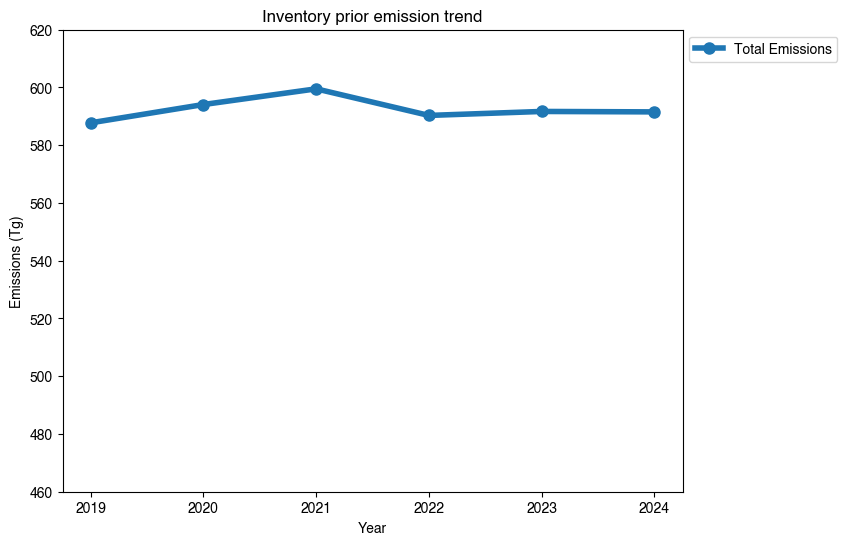

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(df['Year'], df['All Emissions (Tg)'], lw=4, marker='o', markersize=8, label='Total Emissions')
plt.xticks(df['Year'])
plt.ylim(460,620)
plt.xlabel('Year')
plt.ylabel('Emissions (Tg)')
plt.title('Inventory prior emission trend')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### Check EDGAR prior livestock emissions for each year for Colombia

In [11]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
print('Colombia')
mask_colombia = xr.open_dataset('~/integrated_methane_inversion/shapefiles/masks/colombia.nc')
mask_colombia = mask_colombia.rename({'__xarray_dataarray_variable__': 'Mask'})
mask_colombia = mask_colombia['Mask']
for year in years:
    # set directory
    if year == 2019:
        prior_cache = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_burnin/hemco_prior_emis/OutputDir_{year}_inventory'
    else:
        prior_cache = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/hemco_prior_emis/OutputDir_{year}_inventory'

    start_date = f'{year}0101'
    end_date = f'{year+1}0101'

    prior_ds = get_mean_emissions(start_date, end_date, prior_cache)
    prior_livestock = prior_ds["EmisCH4_Livestock"]
    areas = prior_ds["AREA"]

    total_prior_livestock_emissions = sum_total_emissions(prior_livestock, areas, mask_colombia)

    print(f"Prior livestock emissions for {year}: {total_prior_livestock_emissions:.2f} Tg")

Colombia
Prior livestock emissions for 2019: 1.71 Tg
Prior livestock emissions for 2020: 1.75 Tg
Prior livestock emissions for 2021: 1.82 Tg
Prior livestock emissions for 2022: 1.82 Tg
Prior livestock emissions for 2023: 1.82 Tg
Prior livestock emissions for 2024: 1.82 Tg


### Open posterior emissions in each year's inversion

In [3]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
posterior_emissions_all = []
wetland_emissions_all = []
anthro_emissions_all = []
termite_emissions_all = []

for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    areas = posterior_ds["AREA"]

    # make a copy of the original soil sink
    prior_soil_sink = posterior_ds["EmisCH4_SoilAbsorb"].copy()

    # remove the soil sink from the prior total
    posterior = posterior - prior_soil_sink

    wetlands = 0
    anthro = 0
    termites = 0
    for ds_var in list(posterior_ds.keys()):
        if "EmisCH4" in ds_var and "Total" not in ds_var and "Soil" not in ds_var:
            if "Wetlands" in ds_var:
                wetlands = sum_total_emissions(posterior_ds[ds_var], areas, mask)
            elif all(x not in ds_var for x in ("Termites", "Seeps", "Lakes")):
                anthro += sum_total_emissions(posterior_ds[ds_var], areas, mask)
            elif "Termites" in ds_var:
                termites = sum_total_emissions(posterior_ds[ds_var], areas, mask)

    # wetlands = 0
    # anthro = 0
    # for ds_var in list(posterior_ds.keys()):
    #     if "EmisCH4" in ds_var and "Total" not in ds_var and "Soil" not in ds_var:
    #         if "Wetlands" in ds_var or "Livestock" in ds_var:
    #             wetlands += sum_total_emissions(posterior_ds[ds_var], areas, mask)
            # elif any(category in ds_var for category in ["Oil", "Gas", "Coal"]):
            #     anthro += sum_total_emissions(posterior_ds[ds_var], areas, mask)
            # elif "Termites" not in ds_var and "Seeps" not in ds_var and "Lakes" not in ds_var:
            #     anthro += sum_total_emissions(posterior_ds[ds_var], areas, mask)

    # posterior_emissions = float((posterior * areas).sum() * 86400 * 365 * 1e-9)
    posterior_emissions = sum_total_emissions(posterior, areas, mask)

    posterior_emissions_all.append(posterior_emissions)
    wetland_emissions_all.append(wetlands)
    anthro_emissions_all.append(anthro)
    termite_emissions_all.append(termites)
    
posterior_emissions_all = np.array(posterior_emissions_all)
print(posterior_emissions_all)
print(wetland_emissions_all)
print(anthro_emissions_all)
print(termite_emissions_all)

[570.6129929  579.21250882 601.42364036 573.26502353 571.35999125
 575.1273417 ]
[180.44352279280295, 175.4468887022585, 181.21919816493505, 171.27598028140275, 160.2989446278585, 161.54666852254408]
[375.4786661578841, 388.34731689700635, 403.62705756230315, 385.73660683493034, 394.2947807445075, 396.0890804327366]
[12.861765403903581, 13.498213545442601, 14.435608041298426, 14.172871927488774, 14.651921935559793, 15.23134884121927]


In [4]:
# Anthropogenic breakdown
years = [2019, 2020, 2021, 2022, 2023, 2024]
fuel_emissions_all = []
og_emissions_all = []
coal_emissions_all = []
waste_emissions_all = []
livestock_emissions_all = []
rice_emissions_all = []

for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    areas = posterior_ds["AREA"]

    # make a copy of the original soil sink
    prior_soil_sink = posterior_ds["EmisCH4_SoilAbsorb"].copy()

    # remove the soil sink from the prior total
    posterior = posterior - prior_soil_sink

    fuel = 0
    og = 0
    coal = 0
    waste = 0
    livestock = 0
    rice = 0
    for ds_var in list(posterior_ds.keys()):
        if "EmisCH4" in ds_var and "Total" not in ds_var and "Soil" not in ds_var:
            if "Livestock" in ds_var:
                livestock += sum_total_emissions(posterior_ds[ds_var], areas, mask)
            elif "Wastewater" in ds_var or "Landfills" in ds_var:
                waste += sum_total_emissions(posterior_ds[ds_var], areas, mask)
            elif "Oil" in ds_var or "Gas" in ds_var:
                og += sum_total_emissions(posterior_ds[ds_var], areas, mask)
            elif "Coal" in ds_var:
                coal += sum_total_emissions(posterior_ds[ds_var], areas, mask)
            elif "Rice" in ds_var:
                rice += sum_total_emissions(posterior_ds[ds_var], areas, mask)

    # fuel_emissions_all.append(fuel)
    og_emissions_all.append(og)
    coal_emissions_all.append(coal)
    waste_emissions_all.append(waste)
    livestock_emissions_all.append(livestock)
    rice_emissions_all.append(rice)

In [5]:
coal_emissions_all

[22.61276954659545,
 22.231442572988257,
 24.79061186818465,
 22.080991362000297,
 23.130791554013875,
 23.213849798255232]

In [5]:
# check statistics for sectoral changes
sectors = {
    'Oil/Gas':      og_emissions_all,
    'Coal':         coal_emissions_all,
    'Waste':        waste_emissions_all,
    'Livestock':    livestock_emissions_all,
    'Rice':         rice_emissions_all,
    'Wetlands':    wetland_emissions_all
}

records = []
for name, series in sectors.items():
    v2020 = series[years.index(2020)]
    v2021 = series[years.index(2021)]
    abs_diff = v2021 - v2020
    pct_diff = abs_diff / v2020 * 100
    records.append({
        'sector':   name,
        '2020':     v2020,
        '2021':     v2021,
        'abs_diff': abs_diff,
        'pct_diff': pct_diff
    })

# 3) turn it into a DataFrame
df_diff = (
    pd.DataFrame.from_records(records)
      .set_index('sector')
      .round({'2020':2, '2021':2, 'abs_diff':2, 'pct_diff':1})
)

print(df_diff)

print('O/G: ', og_emissions_all)

             2020    2021  abs_diff  pct_diff
sector                                       
Oil/Gas     59.53   56.52     -3.01      -5.1
Coal        22.23   24.79      2.56      11.5
Waste       87.02   91.96      4.94       5.7
Livestock  130.48  139.62      9.15       7.0
Rice        30.72   32.35      1.64       5.3
Wetlands   175.45  181.22      5.77       3.3
O/G:  [55.2578227586059, 59.52983596508086, 56.5156890243052, 54.02854175494641, 52.939210312118064, 50.215302974722434]


In [6]:
# function to identify minimum and maximum ensemble member values
def find_ensemble_range_total(ensemble_scale_path, prior_ds, mask):
    areas = prior_ds["AREA"]
    ens_scale_ds = xr.open_dataset(ensemble_scale_path)
    ensemble_members = ens_scale_ds.ensemble.values

    # compute each member’s total posterior
    ens_totals_posterior = np.array([
        sum_total_emissions(
            get_posterior_emissions(prior_ds, ens_scale_ds.sel(ensemble=mem)["ScaleFactor"])["EmisCH4_Total"],
            areas, mask
        )
        for mem in ensemble_members
    ])

    # locate min/max
    idx_min = np.argmin(ens_totals_posterior)
    idx_max = np.argmax(ens_totals_posterior)

    min_member = ensemble_members[idx_min]
    max_member = ensemble_members[idx_max]
    min_val = ens_totals_posterior[idx_min]+33.554 # remove soil sink
    max_val = ens_totals_posterior[idx_max]+33.554 # remove soil sink

    print(f"Lowest member is {min_member} with total {min_val}")
    print(f"Highest member is {max_member} with total {max_val}")

    return min_val, max_val, min_member, max_member

In [7]:
# attempt 2
years = [2019, 2020, 2021, 2022, 2023, 2024]
total_min_list = []
total_max_list = []
wetlands_min_list = []
wetlands_max_list = []
anthro_min_list = []
anthro_max_list = []

for year in years:
    print(year)
    start_date = f'{year}0101'
    end_date = f'{year+1}0101'
    if year == 2019:
        prior_cache = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/hemco_prior_emis/OutputDir"
        ens_scale_ds_path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/gridded_posterior_ensemble.nc'
    else:
        prior_cache = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/hemco_prior_emis/OutputDir"
        ens_scale_ds_path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/gridded_posterior_ensemble.nc'

    prior_ds = get_mean_emissions(start_date, end_date, prior_cache)
    areas = prior_ds["AREA"]

    posterior_low, posterior_high, posterior_min_member, posterior_max_member = find_ensemble_range_total(ens_scale_ds_path, prior_ds, mask)
    total_min_list.append(posterior_low)
    total_max_list.append(posterior_high)

2019
Lowest member is 8 with total 545.0944661881915
Highest member is 18 with total 577.3166244475512
2020
Lowest member is 8 with total 563.6019269096936
Highest member is 24 with total 595.8448457067345
2021
Lowest member is 8 with total 588.5091584924819
Highest member is 24 with total 616.8988612088812
2022
Lowest member is 8 with total 567.8593306803728
Highest member is 24 with total 579.2547623632446
2023
Lowest member is 8 with total 567.4089436620835
Highest member is 21 with total 572.3440575309841
2024
Lowest member is 8 with total 567.6770502364803
Highest member is 0 with total 577.5616378999541


In [8]:
# function to identify minimum and maximum ensemble member values
def find_ensemble_range_sectoral(ensemble_scale_path, prior_ds, mask):
    areas = prior_ds["AREA"]
    ens_scale_ds = xr.open_dataset(ensemble_scale_path)
    ensemble_members = ens_scale_ds.ensemble.values
    ensemble_posteriors = []
    ensemble_posteriors = [
        get_posterior_emissions(prior_ds, ens_scale_ds.sel(ensemble=mem)["ScaleFactor"])
        for mem in ensemble_members
    ]

    # Find min and max anthro and wetland emissions
    ensemble_wetlands = []
    ensemble_livestock = []
    ensemble_waste = []
    ensemble_og = []
    ensemble_coal = []
    ensemble_rice = []
    ensemble_anthro = []

    natural_sources = ("Termites", "Seeps", "Lakes", "Wetlands")

    for ds in ensemble_posteriors:
        wetlands = livestock = waste = og = coal = rice = anthro = 0
        for ds_var in ds:
            if not ("EmisCH4" in ds_var and "Total" not in ds_var and "Soil" not in ds_var):
                continue

            val = sum_total_emissions(ds[ds_var], areas, mask)

            if "Wetlands" in ds_var:
                wetlands += val
            elif "Livestock" in ds_var:
                livestock += val
            elif "Wastewater" in ds_var or "Landfills" in ds_var:
                waste += val
            elif "Oil" in ds_var or "Gas" in ds_var:
                og += val
            elif "Coal" in ds_var:
                coal += val
            elif "Rice" in ds_var:
                rice += val
            
            # catch all the anthro separately
            if not any(nat in ds_var for nat in natural_sources):
                anthro += val

        ensemble_wetlands.append(wetlands)
        ensemble_livestock.append(livestock)
        ensemble_waste.append(waste)
        ensemble_og.append(og)
        ensemble_coal.append(coal)
        ensemble_rice.append(rice)
        ensemble_anthro.append(anthro)

    ensemble_wetlands = np.array(ensemble_wetlands)
    ensemble_livestock = np.array(ensemble_livestock)
    ensemble_waste = np.array(ensemble_waste)
    ensemble_og = np.array(ensemble_og)
    ensemble_coal = np.array(ensemble_coal)
    ensemble_rice = np.array(ensemble_rice)
    ensemble_anthro = np.array(ensemble_anthro)

    for item in ensemble_members:
        if ensemble_wetlands[item] == ensemble_wetlands.min():
            print("lowest wetlands member is", item)
        elif ensemble_wetlands[item] == ensemble_wetlands.max():
            print("highest wetlands member is", item)
        elif ensemble_anthro[item] == ensemble_anthro.min():
            print("lowest anthro member is", item)
        elif ensemble_anthro[item] == ensemble_anthro.max():
            print("highest anthro member is", item)

    sectors = {
        "Wetlands" : ensemble_wetlands,
        "Livestock": ensemble_livestock,
        "Waste"    : ensemble_waste,
        "Oil/Gas"   : ensemble_og,
        "Coal"     : ensemble_coal,
        "Rice"     : ensemble_rice,
        "Anthropogenic": ensemble_anthro
    }
    df = pd.DataFrame(
        { sector: [arr.min(), arr.max()] for sector, arr in sectors.items() },
        index=["min", "max"]
    )

    return df

    # return ensemble_anthro.min(), ensemble_anthro.max(), ensemble_wetlands.min(), ensemble_wetlands.max()

In [9]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
sectoral_dfs = {}

for year in years:
    start_date = f'{year}0101'
    end_date = f'{year+1}0101'
    if year == 2019:
        prior_cache = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/hemco_prior_emis/OutputDir"
        ens_scale_ds = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/gridded_posterior_ensemble.nc'
    else:
        prior_cache = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/hemco_prior_emis/OutputDir"
        ens_scale_ds = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/gridded_posterior_ensemble.nc'

    prior_ds = get_mean_emissions(start_date, end_date, prior_cache)

    df_sectors = find_ensemble_range_sectoral(ens_scale_ds, prior_ds, mask)
    sectoral_dfs[year] = df_sectors

combined = pd.concat(sectoral_dfs, names=["Year", None])
combined.to_csv("sectoral_ensemble_ranges.csv")

lowest anthro member is 8
highest wetlands member is 9
highest anthro member is 21
lowest wetlands member is 26
highest wetlands member is 0
lowest anthro member is 8
highest anthro member is 24
lowest wetlands member is 26
lowest wetlands member is 8
highest wetlands member is 24
highest wetlands member is 2
lowest anthro member is 8
highest anthro member is 24
lowest wetlands member is 26
highest wetlands member is 0
lowest anthro member is 2
highest anthro member is 24
lowest wetlands member is 26
highest anthro member is 0
lowest anthro member is 8
highest wetlands member is 9
lowest wetlands member is 26


In [11]:
df_sectoral_ensemble = pd.read_csv("sectoral_ensemble_ranges.csv", index_col=[0, 1])
df_sectoral_ensemble

Wetlands   Livestock      Waste    Oil/Gas       Coal       Rice  \
Year                                                                           
2019 min  169.910866  116.549026  80.198773  52.211649  22.188960  34.721365   
     max  183.532615  126.122614  85.971355  56.074837  23.317840  38.389855   
2020 min  169.552791  124.609009  84.468924  56.886133  22.180117  29.534594   
     max  183.436784  138.702059  89.875509  62.526428  23.493497  33.843594   
2021 min  177.601136  134.022997  89.120142  55.719699  22.975740  31.493908   
     max  182.712413  143.532848  95.140653  58.739374  27.289805  34.133646   
2022 min  168.954924  132.307716  87.129127  51.753272  21.806034  30.996045   
     max  175.679343  135.607512  91.417263  54.343735  22.093375  31.771435   
2023 min  155.713626  134.812895  89.572826  51.354214  22.888982  30.580763   
     max  165.852312  141.876374  92.764146  54.630798  23.138890  30.958357   
2024 min  157.213465  138.586988  91.808437  47.621849  22.957106  29.763149   
     max  162.859115  140.718981  95.675002  53.348073  23.347657  31.292210   

          Anthropogenic  
Year                     
2019 min     359.468730  
     max     379.719622  
2020 min     376.136161  
     max     404.771239  
2021 min     394.817792  
     max     416.554019  
2022 min     380.739689  
     max     391.865405  
2023 min     388.378693  
     max     397.625999  
2024 min     390.909852  
     max     398.530551

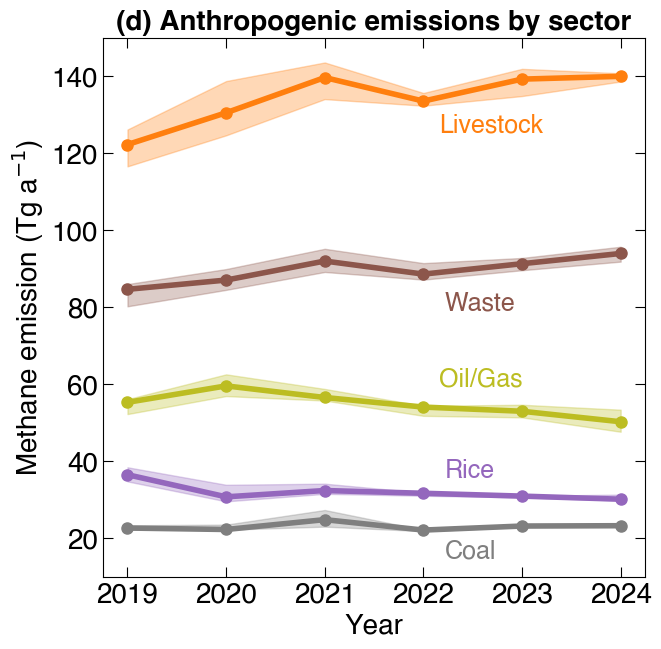

In [18]:
# version 2
fig, ax = plt.subplots(figsize=(7, 7))
plt.rcParams.update({"font.size": 20})

# set color map
num_colors = 20
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

# extract min and max frmo the combined sectors df
df_min = combined.xs("min", level=1)
df_max = combined.xs("max", level=1)

x = np.arange(len(years))

# plot shaded region
ax.fill_between(
    x,
    df_min["Oil/Gas"],
    df_max["Oil/Gas"],
    color=all_colors[16],
    alpha=0.3,
    label="_nolegend_"
)
ax.fill_between(
    x,
    df_min["Coal"],
    df_max["Coal"],
    color=all_colors[14],
    alpha=0.3,
    label="_nolegend_"
)
ax.fill_between(
    x,
    df_min["Waste"],
    df_max["Waste"],
    color=all_colors[10],
    alpha=0.3,
    label="_nolegend_"
)
ax.fill_between(
    x,
    df_min["Livestock"],
    df_max["Livestock"],
    color=all_colors[2],
    alpha=0.3,
    label="_nolegend_"
)
ax.fill_between(
    x,
    df_min["Rice"],
    df_max["Rice"],
    color=all_colors[8],
    alpha=0.3,
    label="_nolegend_"
)

# emissions
# ax.plot(anthro_emissions_all, linewidth=2, marker='o', markersize=6, label='Anthropogenic')
ax.plot(og_emissions_all, linewidth=4, color=all_colors[16], marker='o', markersize=8, label='Oil/gas')
ax.plot(coal_emissions_all, linewidth=4, color=all_colors[14], marker='o', markersize=8, label='Coal')
ax.plot(waste_emissions_all, linewidth=4, color=all_colors[10], marker='o', markersize=8, label='Waste')
ax.plot(livestock_emissions_all, linewidth=4, color=all_colors[2], marker='o', markersize=8, label='Livestock')
ax.plot(rice_emissions_all, linewidth=4, color=all_colors[8], marker='o', markersize=8, label='Rice')

ax.set_ylim(10, 150)
ax.set_xlabel('Year')
ax.set_ylabel('Methane emission (Tg a$^{-1}$)', color='black')
ax.tick_params(axis='y', labelcolor='black')
ax.tick_params(top=True, right=True)
# plot years as x axis
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.tick_params(axis='both', direction='in', length=7)

# ax.spines['right'].set_visible(False) # remove right spine
# ax.spines['top'].set_visible(False) # remove top spine
ax.text(0.62, 0.86, 'Livestock', color=all_colors[2], transform=ax.transAxes, fontsize=18, va='top', ha='left')
ax.text(0.63, 0.53, 'Waste', color=all_colors[10], transform=ax.transAxes, fontsize=18, va='top', ha='left')
ax.text(0.62, 0.39, 'Oil/Gas', color=all_colors[16], transform=ax.transAxes, fontsize=18, va='top', ha='left')
ax.text(0.63, 0.22, 'Rice', color=all_colors[8], transform=ax.transAxes, fontsize=18, va='top', ha='left')
ax.text(0.63, 0.07, 'Coal', color=all_colors[14], transform=ax.transAxes, fontsize=18, va='top', ha='left')
plt.title('(d) Anthropogenic emissions by sector', fontproperties=title_font, fontsize=20)
# slope, _, _, p_value, _ = stats.linregress(years, anthro_emissions_all)
# print(f"Slope: {slope:.2f} Tg a-2, p-value: {p_value:.5f}")
plt.savefig('figures/2d.png', dpi=1200, bbox_inches='tight')
plt.show()

Slope: -1.27 Tg a-2, p-value: 0.09904


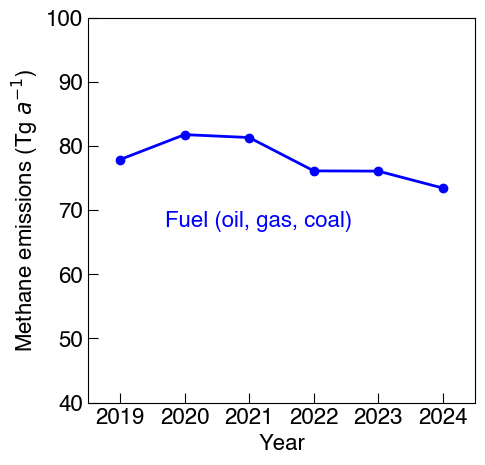

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams.update({"font.size": 16})

years = [2019, 2020, 2021, 2022, 2023, 2024]

# emissions
# ax.plot(wetland_emissions_all, linewidth=2, c='green', marker='o', markersize=6, label='Wetland+livestock emissions')
ax.plot(anthro_emissions_all, linewidth=2, c='blue', marker='o', markersize=6, label='Fuel+waste emissions')

ax.set_ylim(40, 100)
ax.set_xlabel('Year')
ax.set_ylabel('Methane emissions (Tg $a^{-1}$)', color='black')
ax.tick_params(axis='y', labelcolor='black')
# plot years as x axis
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_xlim(-0.5, len(years) - 0.5)
ax.tick_params(axis='both', direction='in', length=7)
ax.text(0.2, 0.5, 'Fuel (oil, gas, coal)', color='blue', transform=ax.transAxes, fontsize=16, va='top', ha='left')
# ax.text(0.2, 0.62, 'Wetlands+livestock', color='green', transform=ax.transAxes, fontsize=16, va='top', ha='left')

slope, _, _, p_value, _ = stats.linregress(years, anthro_emissions_all)
print(f"Slope: {slope:.2f} Tg a-2, p-value: {p_value:.5f}")

plt.show()

In [ ]:
# old
years = [2019, 2020, 2021, 2022, 2023, 2024]

posterior_ensemble_low = []
posterior_ensemble_high = []

anthro_ensemble_low = []
anthro_ensemble_high = []

wetlands_ensemble_low = []
wetlands_ensemble_high = []

for year in years:
    print(year)
    start_date = f'{year}0101'
    end_date = f'{year+1}0101'
    if year == 2019:
        prior_cache = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/hemco_prior_emis/OutputDir"
        ens_scale_ds = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/gridded_posterior_ensemble.nc'
    else:
        prior_cache = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/hemco_prior_emis/OutputDir"
        ens_scale_ds = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/gridded_posterior_ensemble.nc'

    prior_ds = get_mean_emissions(start_date, end_date, prior_cache)

    posterior_low, posterior_high = find_ensemble_range_total(ens_scale_ds, prior_ds, mask)
    anthro_low, anthro_high, wetlands_low, wetlands_high = find_ensemble_range_sectoral(ens_scale_ds, prior_ds, mask)

    posterior_ensemble_low.append(posterior_low+33.545) # remove the soil sink
    posterior_ensemble_high.append(posterior_high+33.545) # remove the soil sink

    anthro_ensemble_low.append(anthro_low)
    anthro_ensemble_high.append(anthro_high)

    wetlands_ensemble_low.append(wetlands_low)
    wetlands_ensemble_high.append(wetlands_high)

posterior_ensemble_low = np.array(posterior_ensemble_low)
posterior_ensemble_high = np.array(posterior_ensemble_high)

anthro_ensemble_low = np.array(anthro_ensemble_low)
anthro_ensemble_high = np.array(anthro_ensemble_high)

wetlands_ensemble_low = np.array(wetlands_ensemble_low)
wetlands_ensemble_high = np.array(wetlands_ensemble_high)

2019
lowest member is 8
highest member is 18
lowest anthro member is 8
highest wetlands member is 9
highest anthro member is 21
lowest wetlands member is 26
2020
lowest member is 8
highest member is 24
highest wetlands member is 0
lowest anthro member is 8
highest anthro member is 24
lowest wetlands member is 26
2021
lowest member is 8
highest member is 24
lowest wetlands member is 8
highest wetlands member is 24
2022
lowest member is 8
highest member is 24
highest wetlands member is 2
lowest anthro member is 8
highest anthro member is 24
lowest wetlands member is 26
2023
lowest member is 8
highest member is 21
highest wetlands member is 0
lowest anthro member is 2
highest anthro member is 24
lowest wetlands member is 26
2024
highest member is 0
lowest member is 8
highest anthro member is 0
lowest anthro member is 8
highest wetlands member is 9
lowest wetlands member is 26


In [45]:
print(posterior_ensemble_low)
print(posterior_ensemble_high)
print(wetlands_ensemble_low)
print(wetlands_ensemble_high)
print(anthro_ensemble_low)
print(anthro_ensemble_high)

[545.08546619 563.59292691 588.50015849 567.85033068 567.39994366
 567.66805024]
[577.30762445 595.83584571 616.88986121 579.24576236 572.33505753
 577.5526379 ]
[169.91086593 169.55279117 177.60113644 168.95492416 155.71362578
 157.21346544]
[183.5326153  183.4367843  182.71241275 175.67934322 165.85231235
 162.85911474]
[359.46873033 376.13616081 394.81779164 380.73968887 388.37869346
 390.90985209]
[379.71962159 404.77123914 416.5540185  391.86540528 397.62599865
 398.5305509 ]


### Get original inventory prior emissions

In [29]:
prior_emissions_all = np.array([554.202, 560.54, 565.97, 556.76, 558.142, 557.99])
prior_emissions_all_nosoil = []
for i in prior_emissions_all:
    i += 33.554
    prior_emissions_all_nosoil.append(i)

prior_emissions_all_nosoil = np.array(prior_emissions_all_nosoil)

### Get methane lifetimes and interhemispheric ratios

In [30]:
lifetimes_all = np.array([10.96, 11.0, 11.14, 11.2, 11.13, 11.047])
interhemispheric_ratios = np.array([1.0173, 1.0108, 1.0095, 1.0084, 1.00998, 1.0065])

In [4]:
# calculate IAV as standard deviation of yearly mean lifetime
IAV = (np.std(lifetimes_all) / np.mean(lifetimes_all)) * 100
print(IAV)
print(np.std(lifetimes_all))

0.758617949742118
0.08405107574167799


In [3]:
print(np.mean(interhemispheric_ratios))
print(np.std(interhemispheric_ratios))

1.0104133333333334
0.0033656434088530254


In [31]:
# Calculate uncertainty in lifetimes
years = [2019, 2020, 2021, 2022, 2023, 2024]
OH_sf_lower_list = []
OH_sf_upper_list = []

for year in years:
    if year == 2019:
        path = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/inversion_result_ensemble.nc"
    else:
        path = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/inversion_result_ensemble.nc"

    ens = xr.open_dataset(path)
    ens_sfs = ens['xhat']

    OH_sfs = ens_sfs.isel(nvar1=slice(-2, None)) # select last two xhat values for each ensemble member (these are the OH SFs)
    mean_OH_sf = OH_sfs.mean(dim='nvar1') # take the mean to get 1 OH SF for each ensemble member

    min_idx = mean_OH_sf.argmin(dim='ensemble').item() # find the ens member of the lowest OH SF (farthest from 1)
    OH_sf_lower = mean_OH_sf.isel(ensemble=min_idx).item() # find the lowest OH SF

    max_idx = mean_OH_sf.argmax(dim='ensemble').item() # find the ens member of the largest OH SF (closest to 1)
    OH_sf_upper = mean_OH_sf.isel(ensemble=max_idx).item() # find the largest OH SF

    # get base OH SF
    OH_sf_base = mean_OH_sf.isel(ensemble=13).item()

    ratio_lower = OH_sf_lower / OH_sf_base
    ratio_upper = OH_sf_upper / OH_sf_base

    OH_sf_lower_list.append(ratio_lower)
    OH_sf_upper_list.append(ratio_upper)

OH_sf_lower_list = np.array(OH_sf_lower_list)
OH_sf_upper_list = np.array(OH_sf_upper_list)

lifetimes_upper = lifetimes_all * OH_sf_lower_list
lifetimes_lower = lifetimes_all * OH_sf_upper_list

ih_ratios_upper = interhemispheric_ratios * OH_sf_lower_list
ih_ratios_lower = interhemispheric_ratios * OH_sf_upper_list

print("Lifetimes")
print(lifetimes_upper)
print(lifetimes_lower)

print("Interhemispheric ratios")
print(ih_ratios_upper)
print(ih_ratios_lower)

Lifetimes
[10.37432744 10.6751757  10.91367309 11.08506607 11.04376665 10.88193255]
[11.13141667 11.07963502 11.19973399 11.23640874 11.15390864 11.08267482]
Interhemispheric ratios
[0.96293826 0.9809516  0.98899039 0.99805184 1.00215485 0.99146059]
[1.03321078 1.01811773 1.01491306 1.01167809 1.01214956 1.00975036]


In [13]:
print(np.mean(interhemispheric_ratios - ih_ratios_upper))
print(np.mean(ih_ratios_lower - interhemispheric_ratios))

0.02298874567167845
0.006223264173265759


In [38]:
df = pd.DataFrame(
    data={"Posterior": posterior_emissions_all,
          "Posterior Low": posterior_ensemble_low,
          "Posterior High": posterior_ensemble_high,
          "Prior": prior_emissions_all_nosoil,
          "CH4 Lifetime": lifetimes_all,
          "Lifetime Low": lifetimes_lower,
          "Lifetime High": lifetimes_upper,
          "Wetlands": wetland_emissions_all,
          "Wetlands Low": wetlands_ensemble_low,
          "Wetlands High": wetlands_ensemble_high,
          "Anthropogenic": anthro_emissions_all,
          "Anthropogenic Low": anthro_ensemble_low,
          "Anthropogenic High": anthro_ensemble_high}, 
    index=years
)

df.index.name = "Year"

In [39]:
df

,Posterior,Posterior Low,Posterior High,Prior,CH4 Lifetime,Lifetime Low,Lifetime High,Wetlands,Wetlands Low,Wetlands High,Anthropogenic,Anthropogenic Low,Anthropogenic High
Year,,,,,,,,,,,,,
2019,570.612993,545.085466,577.307624,587.756,10.960,11.131417,10.374327,180.443523,169.910866,183.532615,375.478666,359.468730,379.719622
2020,579.212509,563.592927,595.835846,594.094,11.000,11.079635,10.675176,175.446889,169.552791,183.436784,388.347317,376.136161,404.771239
2021,601.423640,588.500158,616.889861,599.524,11.140,11.199734,10.913673,181.219198,177.601136,182.712413,403.627058,394.817792,416.554019
2022,573.265024,567.850331,579.245762,590.314,11.200,11.236409,11.085066,171.275980,168.954924,175.679343,385.736607,380.739689,391.865405
2023,571.359991,567.399944,572.335058,591.696,11.130,11.153909,11.043767,160.298945,155.713626,165.852312,394.294781,388.378693,397.625999
2024,575.127342,567.668050,577.552638,591.544,11.047,11.082675,10.881933,161.546669,157.213465,162.859115,396.089080,390.909852,398.530551


In [19]:
df = pd.read_csv("emissions_trend_df.csv")
df.set_index("Year", inplace=True)

In [20]:
def get_growth_rate(emissions):
    print(emissions)
    t = np.arange(len(emissions))
    slope, _, _, p_value, _ = stats.linregress(t, emissions)
    return slope, p_value

In [5]:
emis_2019_2021 = get_growth_rate(np.array(df['Posterior'].iloc[0:3]))
print(f'2019-2021 total growth rate: {emis_2019_2021} Tg a-2')

emis_2021_2024 = get_growth_rate(np.array(df['Posterior'].iloc[2:]))
print(f'2021-2024 total growth rate: {emis_2021_2024} Tg a-2')

emis_trend = get_growth_rate(np.array(df['Posterior']))
print(f'2019-2024 total growth rate: {emis_trend} Tg a-2')

oh_trend = get_growth_rate(np.array(df['CH4 Lifetime']))
print(f'2019-2024 OH trend: {oh_trend}')

[570.6129929  579.21250882 601.42364036]
2019-2021 total growth rate: (15.40532373053611, 0.15898850105328385) Tg a-2
[601.42364036 573.26502353 571.35999125 575.1273417 ]
2021-2024 total growth rate: (-8.079392827635342, 0.2639136143110018) Tg a-2
[570.6129929  579.21250882 601.42364036 573.26502353 571.35999125
 575.1273417 ]
2019-2024 total growth rate: (-0.8326978731166393, 0.8005219019909067) Tg a-2
[10.96  11.    11.14  11.2   11.13  11.047]
2019-2024 OH trend: (0.02528571428571428, 0.2971436345432074)


In [6]:
anthro_2019_2021 = get_growth_rate(np.array(df['Anthropogenic'].iloc[0:3]))
print(f'2019-2021 anthro growth rate: {anthro_2019_2021} Tg a-2')

anthro_2021_2024 = get_growth_rate(np.array(df['Anthropogenic'].iloc[2:]))
print(f'2021-2024 anthro growth rate: {anthro_2021_2024} Tg a-2')

anthro_trend = get_growth_rate(np.array(df['Anthropogenic']))
print(f'2019-2024 anthro growth rate: {anthro_trend} Tg a-2')

wet_2019_2021 = get_growth_rate(np.array(df['Wetlands'].iloc[0:3]))
print(f'2019-2021 wet growth rate: {wet_2019_2021} Tg a-2')

wet_2021_2024 = get_growth_rate(np.array(df['Wetlands'].iloc[2:]))
print(f'2021-2024 wet growth rate: {wet_2021_2024} Tg a-2')

wet_trend = get_growth_rate(np.array(df['Wetlands']))
print(f'2019-2024 wet growth rate: {wet_trend} Tg a-2')

[390.16947338 403.7656209  420.2044421 ]
2019-2021 anthro growth rate: (15.017484360488538, 0.034752625483499375) Tg a-2
[420.2044421  401.98904254 411.06104683 413.58067666]
2021-2024 anthro growth rate: (-1.079929202571219, 0.8151050784005633) Tg a-2
[390.16947338 403.7656209  420.2044421  401.98904254 411.06104683
 413.58067666]
2019-2024 anthro growth rate: (3.4493398465176632, 0.1949675204992218) Tg a-2
[180.44352279 175.4468887  181.21919816]
2019-2021 wet growth rate: (0.3878376860660637, 0.9209850054593043) Tg a-2
[181.21919816 171.27598028 160.29894463 161.54666852]
2021-2024 wet growth rate: (-6.999462458071716, 0.07299801218481293) Tg a-2
[180.44352279 175.4468887  181.21919816 171.27598028 160.29894463
 161.54666852]
2019-2024 wet growth rate: (-4.282037755943613, 0.020736459688455926) Tg a-2


In [49]:
prior_mean = df['Prior'].mean()

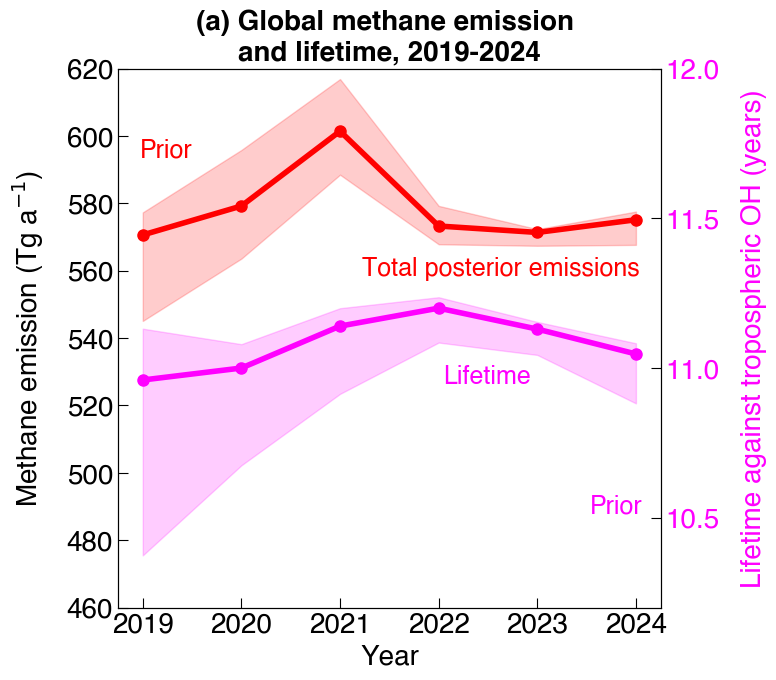

In [22]:
plt.rcParams.update({"font.size": 20})
fig, ax1 = plt.subplots(figsize=(7, 7)) # previously (9,7)

# emissions
# ax1.plot(df["Prior"], linewidth=4, linestyle='--', c='black', marker='o', markersize=8, label='Prior (inventory) emissions')
ax1.plot(df["Posterior"], linewidth=4, c='red', marker='o', markersize=8, label='Posterior emissions')
# Uncertainty bounds (ensemble spread)
ax1.fill_between(df.index, df["Posterior Low"], df["Posterior High"], color='red', alpha=0.2)
ax1.set_ylim(460, 620)
ax1.set_xlabel('Year')
ax1.set_ylabel('Methane emission (Tg a$^{-1}$)', color='black', labelpad=15)
ax1.tick_params(axis='y', labelcolor='black')
# ax1.text(0.55, 0.9, 'Total prior emissions', color='black', transform=ax1.transAxes, fontsize=18, va='top', ha='left')
ax1.text(0.45, 0.65, 'Total posterior emissions', color='red', transform=ax1.transAxes, fontsize=18, va='top', ha='left')
ax1.text(0.04, 0.87, 'Prior', color='red', transform=ax1.transAxes, fontsize=18, va='top', ha='left')
ax1.set_xticks(df.index)
ax1.set_xticklabels(df.index.astype(int))
ax1.tick_params(axis='both', direction='in', length=7)

# CH4 lifetime
ax2 = ax1.twinx()
ax2.plot(df["CH4 Lifetime"], linewidth=4, c='magenta', marker='o', markersize=8, label='Lifetime against OH')
ax2.fill_between(df.index, df["Lifetime Low"], df["Lifetime High"], color='magenta', alpha=0.2)
ax2.set_ylim(10.2, 12)
ax2.set_ylabel('Lifetime against tropospheric OH (years)', color='magenta', labelpad=15)
ax2.tick_params(axis='y', direction='in', length=7, labelcolor='magenta')
# only ticks every 0.5
ax2.set_yticks([10.5, 11, 11.5, 12])
ax2.text(0.6, 0.45, 'Lifetime', color='magenta', transform=ax2.transAxes, fontsize=18, va='top', ha='left')
ax2.text(0.87, 0.21, 'Prior', color='magenta', transform=ax2.transAxes, fontsize=18, va='top', ha='left')

plt.title('(a) Global methane emission \nand lifetime, 2019-2024', fontproperties=title_font, fontsize=20)
plt.savefig('figures/2a.png', dpi=1200, bbox_inches='tight')
plt.show()


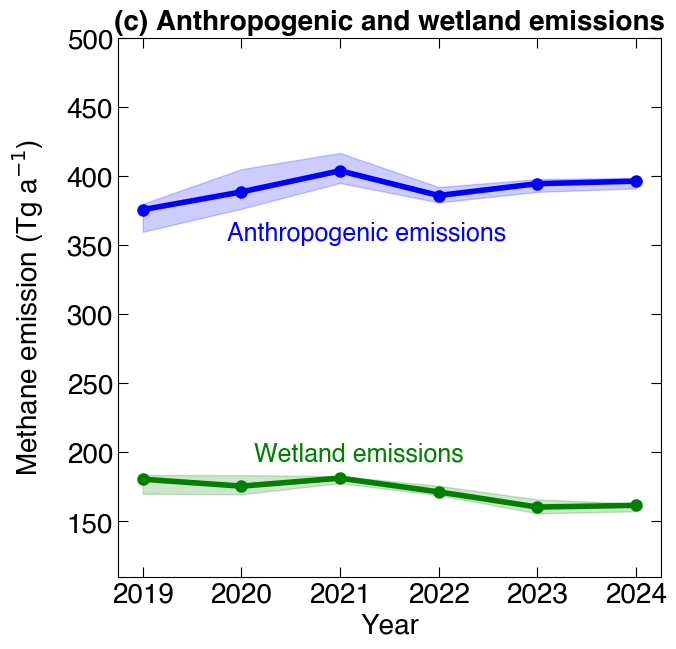

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))
plt.rcParams.update({"font.size": 20})

# emissions
ax.plot(df["Wetlands"], linewidth=4, c='green', marker='o', markersize=8, label='Wetland emissions')
ax.plot(df["Anthropogenic"], linewidth=4, c='blue', marker='o', markersize=8, label='Anthropogenic emissions')
# uncertainty bounds (ensemble spread)
ax.fill_between(df.index, df["Wetlands Low"], df["Wetlands High"], color='green', alpha=0.2)
ax.fill_between(df.index, df["Anthropogenic Low"], df["Anthropogenic High"], color='blue', alpha=0.2)

ax.set_ylim(110, 500) # 120,450
ax.set_xlabel('Year')
ax.set_ylabel('Methane emission (Tg a$^{-1}$)', color='black', labelpad=15)
ax.tick_params(axis='y', labelcolor='black')
ax.tick_params(top=True, right=True)

ax.set_xticks(df.index)
ax.set_xticklabels(df.index.astype(int))
ax.tick_params(axis='both', direction='in', length=7)
ax.text(0.2, 0.66, 'Anthropogenic emissions', color='blue', transform=ax.transAxes, fontsize=18, va='top', ha='left') # 0.2, 0.74
ax.text(0.25, 0.25, 'Wetland emissions', color='green', transform=ax.transAxes, fontsize=18, va='top', ha='left') # 0.25, 0.23

plt.title('(c) Anthropogenic and wetland emissions', fontproperties=title_font, fontsize=20)
plt.savefig('figures/2c.png', dpi=1200, bbox_inches='tight')
plt.show()

## Regional analysis

In [3]:
years = [2019, 2020, 2021, 2022, 2023, 2024]

def plot_regional_timeseries(years, mask_region):

    posterior_emissions_region = []
    wetland_emissions_region = []
    anthro_emissions_region = []
    rice_emissions_region = []

    for year in years:
        # set directory
        if year == 2019:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
        else:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
        posterior_ds = xr.load_dataset(path)
        posterior = posterior_ds["EmisCH4_Total"]
        posterior_rice = posterior_ds["EmisCH4_Rice"]
        areas = posterior_ds["AREA"]

        # make a copy of the original soil sink
        prior_soil_sink = posterior_ds["EmisCH4_SoilAbsorb"].copy()

        # remove the soil sink from the prior total
        posterior = posterior - prior_soil_sink

        wetlands_livestock = 0
        fuel_waste = 0
        for ds_var in list(posterior_ds.keys()):
            if "EmisCH4" in ds_var and "Total" not in ds_var and "Soil" not in ds_var:
                if "Wetlands" in ds_var or "Livestock" in ds_var:
                # if "Wetlands" in ds_var:
                    wetlands_livestock += sum_total_emissions(posterior_ds[ds_var], areas, mask_region)
                elif any(category in ds_var for category in ["Oil", "Gas", "Coal", "Wastewater", "Landfills"]):
                    fuel_waste += sum_total_emissions(posterior_ds[ds_var], areas, mask_region)
                # elif "Termites" not in ds_var and "Seeps" not in ds_var and "Lakes" not in ds_var:
                #     anthro += sum_total_emissions(posterior_ds[ds_var], areas, mask_region)

        posterior_emissions = sum_total_emissions(posterior, areas, mask_region)
        posterior_emissions_rice = sum_total_emissions(posterior_rice, areas, mask_region)

        posterior_emissions_region.append(posterior_emissions)
        wetland_emissions_region.append(wetlands_livestock)
        anthro_emissions_region.append(fuel_waste)
        rice_emissions_region.append(posterior_emissions_rice)
        
    posterior_emissions_region = np.array(posterior_emissions_region)

    plt.rcParams.update({"font.size": 16})
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.plot(years, posterior_emissions_region, linewidth=4, c='red', label='Posterior emissions')
    ax.plot(years, wetland_emissions_region, linewidth=4, c='green', label='Wetland+livestock emissions')
    ax.plot(years, anthro_emissions_region, linewidth=4, c='blue', label='Fuel+waste emissions')

    ax.set_ylim(0,110)
    ax.set_xlabel('Year')
    ax.set_ylabel('Methane emissions (Tg $a^{-1}$)', color='black')
    ax.tick_params(axis='y', labelcolor='black')
    ax.set_xticks(years)
    ax.set_xticklabels(years)

    plt.show() 

    return posterior_emissions_region, wetland_emissions_region, anthro_emissions_region, rice_emissions_region

### Africa trend

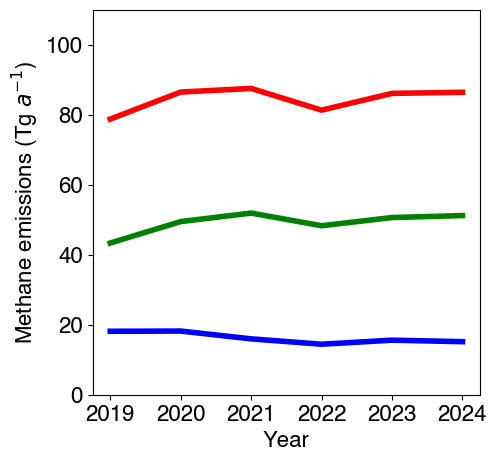

[78.74718813 86.4749365  87.51188617 81.30659066 86.09393605 86.40688822]
[78.74718813 86.4749365  87.51188617]
[43.34425095232424, 49.4661674964304, 51.897425693458395, 48.278610623221994, 50.623617902254026, 51.179616529927095]
[18.13126111795365, 18.193224971171123, 15.960867537083907, 14.428779663923432, 15.586751760409365, 15.155964388338225]
[1.5722705763913012, 1.6648062007994977, 1.5786443534724959, 1.3496370190264004, 1.4398802026894248, 1.7176965761619325]
Total: 0.88 Tg a-2, p-value: 0.35
Total 2019-2021: 4.38 Tg a-2, p-value: 0.26
Wetland+livestock: 1.12 Tg a-2, p-value: 0.14
Fuel+waste: -0.69 Tg a-2, p-value: 0.04
Biomass: -0.01 Tg a-2, p-value: 0.90


In [8]:
mask_africa = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/africa.nc')
africa_total, africa_wetlands, africa_anthro, africa_biomass = plot_regional_timeseries(years, mask_africa)

slope_total, p_total = get_growth_rate(africa_total)
slope_2019_2021, p_2019_2021 = get_growth_rate(africa_total[:3])
slope_wet, p_wet = get_growth_rate(africa_wetlands)
slope_fuel, p_fuel = get_growth_rate(africa_anthro)
slope_biomass, p_biomass = get_growth_rate(africa_biomass)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Total 2019-2021: {slope_2019_2021:.2f} Tg a-2, p-value: {p_2019_2021:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")
print(f"Biomass: {slope_biomass:.2f} Tg a-2, p-value: {p_biomass:.2f}")

### East Africa

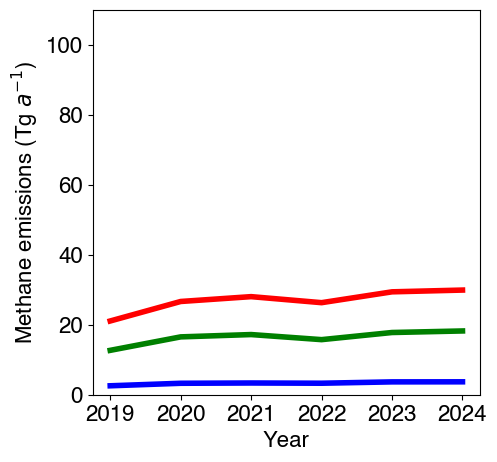

[21.06751196 26.63939959 28.0224878  26.30077389 29.3967636  29.89931884]
[12.678193502532535, 16.526450261124637, 17.18855305369184, 15.738397768349852, 17.774749786517322, 18.21802897412973]
[2.5524667440449584, 3.269675409880675, 3.3497424897992447, 3.2841391701976077, 3.6684582388096887, 3.6868959752344908]
[0.9043410191908544, 1.1144190781103098, 1.278739136465773, 1.0682178944335086, 1.1530402052307995, 1.441964040639006]
Total: 1.45 Tg a-2, p-value: 0.03
Wetland+livestock: 0.86 Tg a-2, p-value: 0.06
Fuel+waste: 0.19 Tg a-2, p-value: 0.02
Biomass: 0.07 Tg a-2, p-value: 0.08


In [9]:
mask_africa = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/east_africa.nc')
africa_total, africa_wetlands, africa_anthro, africa_biomass = plot_regional_timeseries(years, mask_africa)

slope_total, p_total = get_growth_rate(africa_total)
slope_wet, p_wet = get_growth_rate(africa_wetlands)
slope_fuel, p_fuel = get_growth_rate(africa_anthro)
slope_biomass, p_biomass = get_growth_rate(africa_biomass)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")
print(f"Biomass: {slope_biomass:.2f} Tg a-2, p-value: {p_biomass:.2f}")

### South America

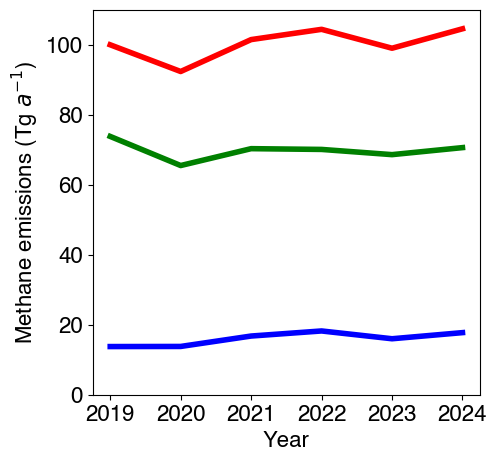

[ 99.97530264  92.34797126 101.46609729 104.3948586   98.99916735
 104.55216182]
[ 99.97530264  92.34797126 101.46609729]
[73.79733750605745, 65.48216234868573, 70.3030076651751, 70.0845251885091, 68.59601979533167, 70.6018507711155]
[13.75971902844415, 13.792239690142972, 16.766799087970846, 18.217497934705335, 15.99165648953373, 17.741345905816527]
[1.344477954540244, 0.831142210398135, 0.8599186424334029, 0.8056958730888389, 0.8000987759558974, 0.9295776388593675]
Total: 1.31 Tg a-2, p-value: 0.26
Total 2019-2021: 0.75 Tg a-2, p-value: 0.90
Wetland+livestock: -0.20 Tg a-2, p-value: 0.80
Fuel+waste: 0.80 Tg a-2, p-value: 0.07
Biomass: -0.06 Tg a-2, p-value: 0.24


In [6]:
mask_SA = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/SA.nc')
SA_total, SA_wetlands, SA_anthro, SA_biomass = plot_regional_timeseries(years, mask_SA)

slope_total, p_total = get_growth_rate(SA_total)
slope_2019_2021, p_2019_2021 = get_growth_rate(SA_total[:3])
slope_wet, p_wet = get_growth_rate(SA_wetlands)
slope_fuel, p_fuel = get_growth_rate(SA_anthro)
slope_biomass, p_biomass = get_growth_rate(SA_biomass)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Total 2019-2021: {slope_2019_2021:.2f} Tg a-2, p-value: {p_2019_2021:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")
print(f"Biomass: {slope_biomass:.2f} Tg a-2, p-value: {p_biomass:.2f}")

### China

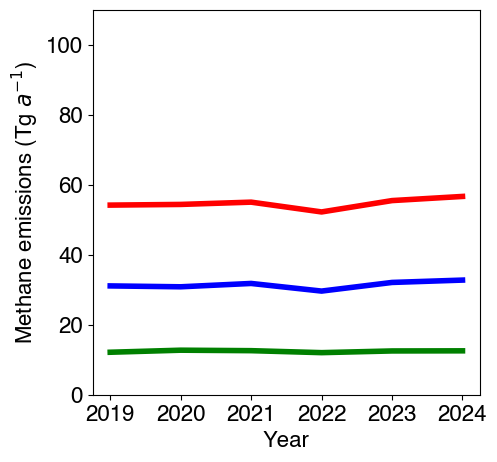

[54.1749574  54.36883765 55.02156741 52.2236946  55.46855352 56.65326677]
[12.13682104612484, 12.722055583361254, 12.587056878588427, 12.022018103622141, 12.505380070891349, 12.541015784938653]
[31.089573656934576, 30.836880940038625, 31.790737467689837, 29.61177176098625, 32.08016682099737, 32.750663878058724]
[7.40497307652902, 7.213387316276895, 7.204024666031503, 7.705611524925572, 7.707965399356248, 8.26545282575636]
Total: 0.37 Tg a-2, p-value: 0.35
Wetland+livestock: 0.02 Tg a-2, p-value: 0.77
Fuel+waste: 0.28 Tg a-2, p-value: 0.34
Rice: 0.18 Tg a-2, p-value: 0.04


In [ ]:
# THIS IS RICE, CHANGE BACK IN PARENT CODE

mask_china = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/china.nc')
china_total, china_wetlands, china_anthro, china_rice = plot_regional_timeseries(years, mask_china)

slope_total, p_total = get_growth_rate(china_total)
slope_wet, p_wet = get_growth_rate(china_wetlands)
slope_fuel, p_fuel = get_growth_rate(china_anthro)
slope_rice, p_rice = get_growth_rate(china_rice)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")
print(f"Rice: {slope_rice:.2f} Tg a-2, p-value: {p_rice:.2f}")

### CONUS

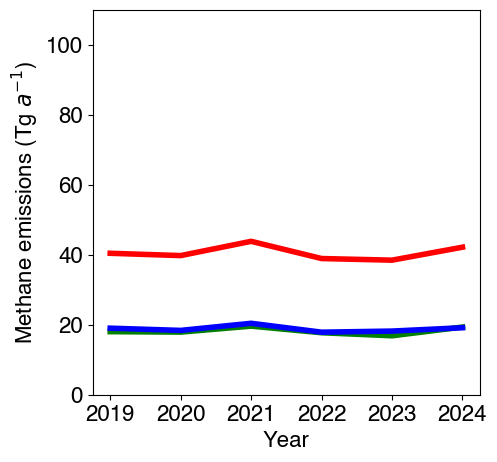

40.5835426519678
[40.41291419 39.75189038 43.82963599 38.90726811 38.44642585 42.15312139]
[18.022186969606135, 17.888438217653952, 19.60085450553511, 17.710070234861018, 16.84346789508279, 19.333723080133694]
[19.012887309106823, 18.37690111096541, 20.405595183564273, 17.867411271332752, 18.183537620987877, 19.144621215599905]
Total: -0.00 Tg a-2, p-value: 0.99
Wetland+livestock: 0.04 Tg a-2, p-value: 0.88
Fuel+waste: -0.07 Tg a-2, p-value: 0.79


In [24]:
mask_CONUS = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/conus.nc')
CONUS_total, CONUS_wetlands, CONUS_anthro, _ = plot_regional_timeseries(years, mask_CONUS)

print(np.mean(CONUS_total))

slope_total, p_total = get_growth_rate(CONUS_total)
slope_wet, p_wet = get_growth_rate(CONUS_wetlands)
slope_fuel, p_fuel = get_growth_rate(CONUS_anthro)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")

### Europe

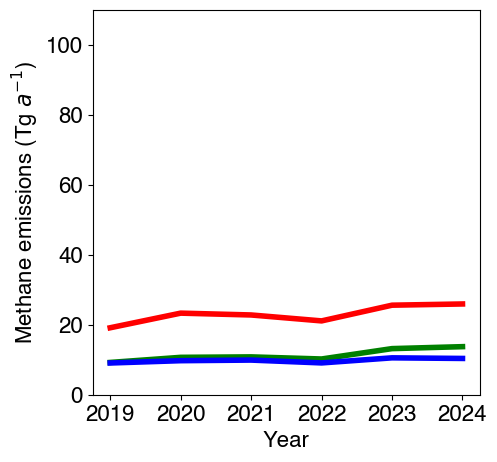

[19.13171862 23.30915463 22.78512205 21.09171346 25.58064914 25.92955821]
[9.222732608221271, 10.680714664468999, 10.811956200083845, 10.207741544463765, 13.173108755421083, 13.731907739118464]
[9.064506671803485, 9.722553527280903, 9.897405135319296, 9.085875965497586, 10.537958943829924, 10.364557628787049]
Total: 1.12 Tg a-2, p-value: 0.05
Wetland+livestock: 0.84 Tg a-2, p-value: 0.02
Fuel+waste: 0.23 Tg a-2, p-value: 0.12


In [14]:
mask_europe = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/europe.nc')
europe_total, europe_wetlands, europe_anthro, _ = plot_regional_timeseries(years, mask_europe)

slope_total, p_total = get_growth_rate(europe_total)
slope_wet, p_wet = get_growth_rate(europe_wetlands)
slope_fuel, p_fuel = get_growth_rate(europe_anthro)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")

### Canada

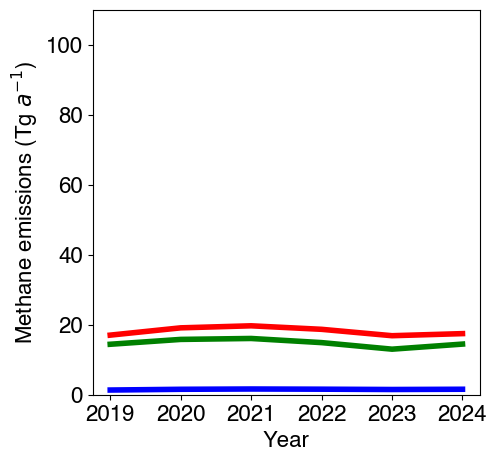

[17.02530819 19.10726241 19.69037563 18.68610169 16.86133644 17.45554346]
[14.417928977369955, 15.803336220051495, 16.07126801962378, 14.888761211579657, 13.013975182265401, 14.465458610108424]
[1.3400924819521032, 1.5505868975747712, 1.6354095589909112, 1.5809846148189894, 1.4920813983027696, 1.5627707626993605]
[0.28888490889871904, 0.47003240512220584, 0.474817824455121, 0.4729405311510303, 0.2898976688781758, 0.31429605393944854]
Total: -0.16 Tg a-2, p-value: 0.63
Wetland+livestock: -0.27 Tg a-2, p-value: 0.37
Fuel+waste: 0.03 Tg a-2, p-value: 0.36
Biomass: -0.01 Tg a-2, p-value: 0.66


In [25]:
mask_canada = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/canada.nc')
canada_total, canada_wetlands, canada_anthro, canada_biomass = plot_regional_timeseries(years, mask_canada)

slope_total, p_total = get_growth_rate(canada_total)
slope_wet, p_wet = get_growth_rate(canada_wetlands)
slope_fuel, p_fuel = get_growth_rate(canada_anthro)
slope_biomass, p_biomass = get_growth_rate(canada_biomass)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")
print(f"Biomass: {slope_biomass:.2f} Tg a-2, p-value: {p_biomass:.2f}")

### SE Asia

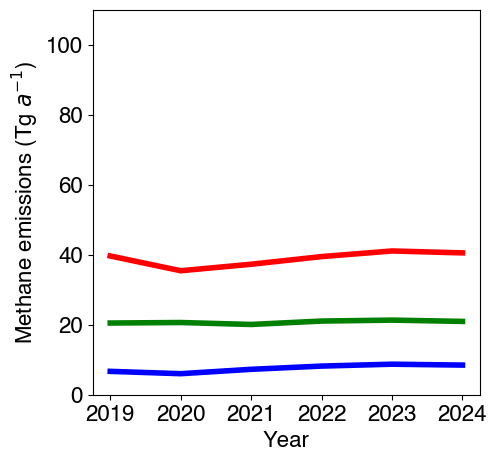

[39.64316237 35.42360716 37.27950171 39.4663767  41.07115056 40.52508573]
[20.48432790340648, 20.629384714609316, 20.075924359136383, 21.046190147596523, 21.317461968867576, 20.94743251852747]
[6.676618424573668, 6.008996202540648, 7.257530569907946, 8.18169146672998, 8.722241604772806, 8.465603210885963]
Total: 0.67 Tg a-2, p-value: 0.22
Wetland+livestock: 0.15 Tg a-2, p-value: 0.17
Fuel+waste: 0.51 Tg a-2, p-value: 0.02


In [6]:
mask_sea = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/southeast-asia.nc')
sea_total, sea_wetlands, sea_anthro, _ = plot_regional_timeseries(years, mask_sea)

slope_total, p_total = get_growth_rate(sea_total)
slope_wet, p_wet = get_growth_rate(sea_wetlands)
slope_fuel, p_fuel = get_growth_rate(sea_anthro)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")

### Middle East

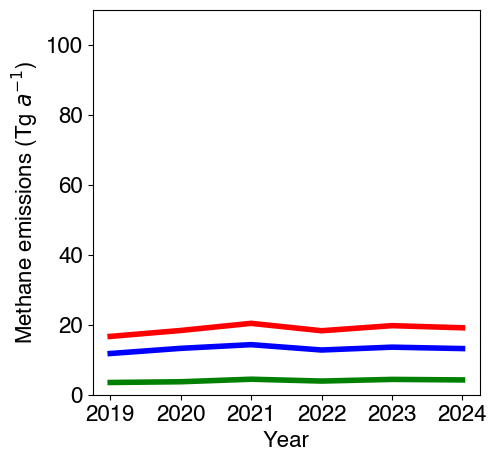

[16.66130083 18.35550771 20.39560787 18.28252761 19.73309186 19.1228738 ]
[3.493005519591521, 3.7088889414710366, 4.428277519257253, 3.9037370970005245, 4.377792745066207, 4.230349209695942]
[11.772415718868661, 13.251103221268153, 14.303850068829046, 12.776678215736862, 13.589216278772533, 13.185209222745488]
[3.265468390097341, 3.459033671505364, 4.113733503756938, 3.6285873198327994, 4.061270615075315, 3.92462620220176]
Total: 0.41 Tg a-2, p-value: 0.22
Wetland+livestock: 0.15 Tg a-2, p-value: 0.10
Fuel+waste: 0.19 Tg a-2, p-value: 0.41
Livestock: 0.13 Tg a-2, p-value: 0.11


In [ ]:
# CHANGE FUNCTION IF RERUNNING THIS (FUNCTION IS CURRENTLY BIOMASS)
mask_me = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/middle-east.nc')
me_total, me_wetlands, me_anthro, me_livestock = plot_regional_timeseries(years, mask_me)

slope_total, p_total = get_growth_rate(me_total)
slope_wet, p_wet = get_growth_rate(me_wetlands)
slope_fuel, p_fuel = get_growth_rate(me_anthro)
slope_livestock, p_livestock = get_growth_rate(me_livestock)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")
print(f"Livestock: {slope_livestock:.2f} Tg a-2, p-value: {p_livestock:.2f}")

### Russia

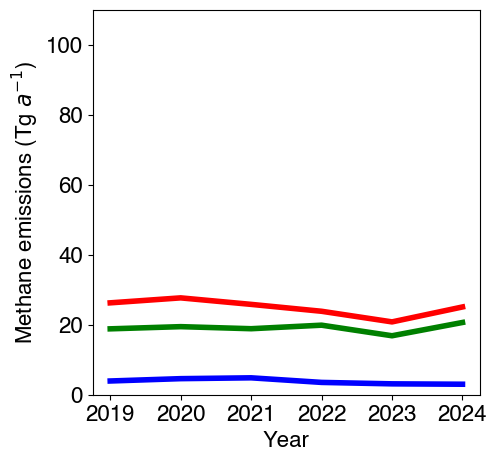

[26.25162114 27.67215275 25.81339041 23.84141584 20.80861363 25.07562284]
[18.824035172291765, 19.449203658573346, 18.85911687455722, 19.8684984917978, 16.84679032832632, 20.643138341579665]
[3.9229023395244313, 4.590634782767442, 4.829471837679038, 3.5176267546158186, 3.1086700550008213, 2.9981985903346637]
Total: -0.81 Tg a-2, p-value: 0.17
Wetland+livestock: 0.07 Tg a-2, p-value: 0.86
Fuel+waste: -0.30 Tg a-2, p-value: 0.10


In [11]:
mask_russia = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/russia.nc')
russia_total, russia_wetlands, russia_anthro, _ = plot_regional_timeseries(years, mask_russia)

slope_total, p_total = get_growth_rate(russia_total)
slope_wet, p_wet = get_growth_rate(russia_wetlands)
slope_fuel, p_fuel = get_growth_rate(russia_anthro)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")

### India + Pakistan

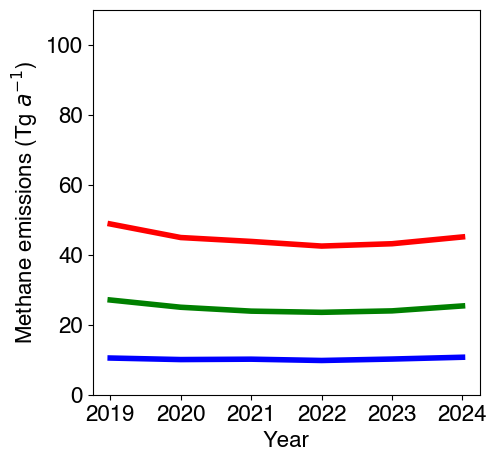

[48.79146931 44.91178585 43.79674344 42.47260536 43.13779299 45.08411487]
[27.06716255458327, 24.99461475183933, 23.882482189088876, 23.54206127403334, 23.957687786263286, 25.36883773303159]
[10.485134066974236, 10.044006560314354, 10.155117638358625, 9.782862638823254, 10.192251225780815, 10.708219264492566]
Total: -0.72 Tg a-2, p-value: 0.21
Wetland+livestock: -0.34 Tg a-2, p-value: 0.33
Fuel+waste: 0.03 Tg a-2, p-value: 0.71


In [5]:
mask_south_asia = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/south-asia.nc')
south_asia_total, south_asia_wetlands, south_asia_anthro, _ = plot_regional_timeseries(years, mask_south_asia)

slope_total, p_total = get_growth_rate(south_asia_total)
slope_wet, p_wet = get_growth_rate(south_asia_wetlands)
slope_fuel, p_fuel = get_growth_rate(south_asia_anthro)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")

### Central Asia

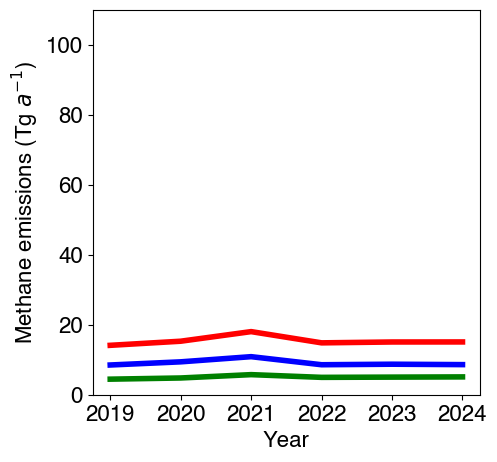

[14.11410739 15.28701946 18.02941876 14.82062395 15.06611848 15.08033572]
[4.4454697269053085, 4.782765086628979, 5.737604041887678, 4.960691098316413, 5.029365314748398, 5.093277808573383]
[8.492172881810252, 9.3953300912471, 10.87210263945587, 8.566263690147572, 8.718991098630655, 8.59952225430537]
Total: 0.03 Tg a-2, p-value: 0.94
Wetland+livestock: 0.09 Tg a-2, p-value: 0.43
Fuel+waste: -0.11 Tg a-2, p-value: 0.68


In [6]:
mask_central_asia = xr.open_dataarray('~/integrated_methane_inversion/shapefiles/masks/central-asia.nc')
central_asia_total, central_asia_wetlands, central_asia_anthro, _ = plot_regional_timeseries(years, mask_central_asia)

slope_total, p_total = get_growth_rate(central_asia_total)
slope_wet, p_wet = get_growth_rate(central_asia_wetlands)
slope_fuel, p_fuel = get_growth_rate(central_asia_anthro)
print(f"Total: {slope_total:.2f} Tg a-2, p-value: {p_total:.2f}")
print(f"Wetland+livestock: {slope_wet:.2f} Tg a-2, p-value: {p_wet:.2f}")
print(f"Fuel+waste: {slope_fuel:.2f} Tg a-2, p-value: {p_fuel:.2f}")

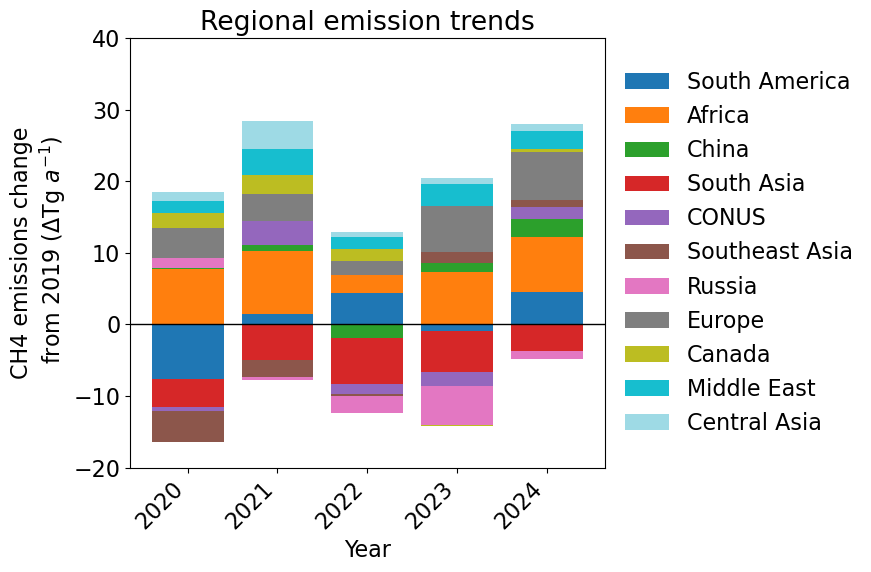

In [39]:
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(9, 6))

num_colors = 11
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

years_all = [2019, 2020, 2021, 2022, 2023, 2024]  # Includes 2019 for reference
years_plot = [2020, 2021, 2022, 2023, 2024]  # Only years to be plotted
regions = ['South America', 'Africa', 'China', 'South Asia', 'CONUS', 
           'Southeast Asia', 'Russia', 'Europe', 'Canada', 'Middle East', 'Central Asia']
data = np.array([SA_total, africa_total, china_total, south_asia_total, 
                 CONUS_total, sea_total, russia_total, europe_total, 
                 canada_total, me_total, central_asia_total])

# Compute change relative to 2019 (first year)
data_relative = data[:, 1:] - data[:, 0].reshape(-1, 1)

# Create separate stacks for positive and negative changes
bottom_positive = np.zeros(len(years_plot))
bottom_negative = np.zeros(len(years_plot))

region_handles = {} # one handle per region to avoid duplicates in legend

# Create stacked bar plot
for i, (region, values, color) in enumerate(zip(regions, data_relative, all_colors)):
    values = np.array(values)

    # Identify positive and negative changes to avoid bars that overlap 0
    positive = np.where(values > 0, values, 0)
    negative = np.where(values < 0, values, 0)

    # stack positives together
    bars_pos = ax.bar(years_plot, positive, bottom=bottom_positive, label=region, color=color)
    bottom_positive += positive  # Update bottom for stacking

    # stack negatives together
    bars_neg = ax.bar(years_plot, negative, bottom=bottom_negative, label=region, color=color)
    bottom_negative += negative

    # store one handle per sector to avoid duplicates in legend
    if region not in region_handles:
        region_handles[region] = bars_pos[0] if any(positive) else bars_neg[0]
    

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(years_plot)
ax.set_xticklabels(years_plot, rotation=45, ha="right")
ax.set_xlabel('Year')
ax.set_ylabel("CH4 emissions change\n from 2019 ($\\Delta$Tg $a^{-1}$)")
ax.set_title('Regional emission trends')
ax.set_ylim(-20, 40)

# one handle per region for legend
handles = list(region_handles.values())
labels = list(region_handles.keys())
ax.legend(handles, regions, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout()
plt.show()

### Sandchart

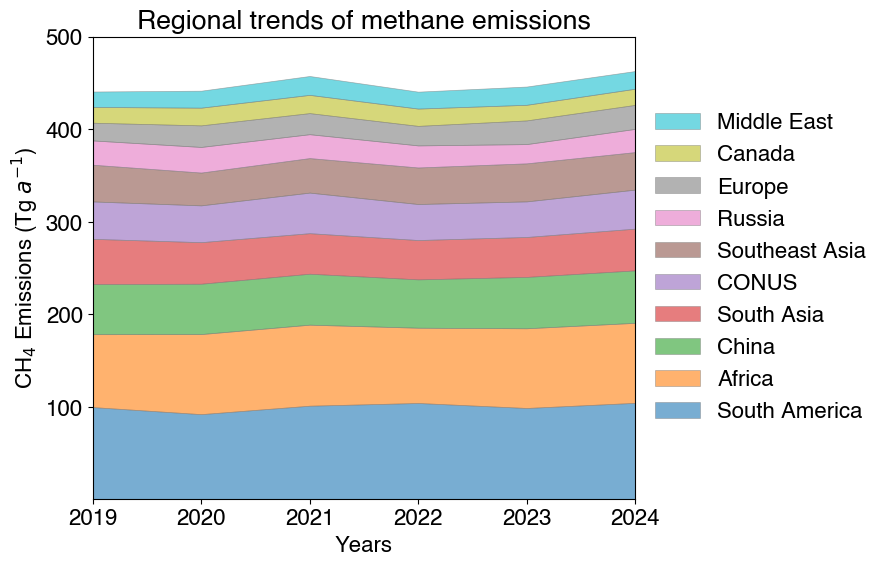

In [44]:
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(7, 6))

ax.stackplot(years,
              SA_total, 
              africa_total,
              china_total,
              south_asia_total, 
              CONUS_total,
              sea_total,
              russia_total,
              europe_total,
              canada_total,            
              me_total,
              labels=['South America', 'Africa', 'China', 'South Asia', 'CONUS', 'Southeast Asia', 'Russia', 'Europe', 'Canada', 'Middle East'],
              alpha=0.6,
              edgecolor='grey',
              linewidth=0.5)

ax.set_ylim(1,500)
ax.tick_params(axis='y', labelcolor='black')
ax.set_xlim([years[0], years[-1]])
ax.set_xticks(years)
ax.set_xticklabels(years)
ax.set_xlabel('Years')
ax.set_ylabel(r'CH$_4$ Emissions (Tg $a^{-1}$)')
ax.set_title('Regional trends of methane emissions')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.show()

In [ ]:
years = [2019, 2020, 2021, 2022, 2023, 2024]

def sectoral_attribution(years, mask_region, total):
    sectors = ["Oil",
               "Gas",
               "Coal",
               "Livestock",
               "Landfills",
               "Wastewater",
               "Rice",
               "OtherAnth",
               "BiomassBurn",
               "Reservoirs"]
    
    regional_timeseries = []
    
    for year in years:
        if year == 2019:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
        else:
            path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
        posterior_ds = xr.load_dataset(path)
        areas = posterior_ds["AREA"]

        sector_all = [] # sectoral emissions for the current year

        for sector in sectors:
            posterior = posterior_ds[f"EmisCH4_{sector}"]
            sectoral_emission = sum_total_emissions(posterior, areas, mask_region)
            sector_all.append(sectoral_emission)

        regional_timeseries.append(sector_all)

    # turn into dataframe 
    df = pd.DataFrame(regional_timeseries, index=years, columns=sectors)
    print(df)

    # plot
    plt.rcParams.update({"font.size": 16})
    fig, ax = plt.subplots(figsize=(7, 6))

    emis = df.columns
    values = [df[col].values for col in emis]

    ax.stackplot(df.index,
                 values,
                 labels=sectors,
                 alpha=0.6,
                 edgecolor='grey',
                 linewidth=0.5)
    
    ax.plot(years, total, color='black', linewidth=2, marker='o', markersize=6, label="Total", clip_on=False)

    ax.tick_params(axis='y', labelcolor='black')
    ax.set_xlim([years[0], years[-1]])
    ax.set_xticks(years)
    ax.set_xticklabels(years)
    ax.set_xlabel('Years')
    ax.set_ylabel(r'CH$_4$ Emissions (Tg $a^{-1}$)')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)


    plt.show()


           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  0.192318  1.866685  0.930433   7.526558   3.230891    1.620652   
2020  0.202183  1.953781  0.996448   8.265457   3.343315    1.938138   
2021  0.210073  1.923961  0.943966   8.792156   3.651089    1.834617   
2022  0.199561  1.750421  0.748970   8.306527   3.453245    1.670339   
2023  0.236369  1.985188  0.933768  10.983249   3.939346    1.938417   
2024  0.238714  2.024583  0.681807  11.459083   3.970882    1.941404   

          Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  0.233475   1.223529     0.127243   -0.096883  
2020  0.242765   1.288690     0.132134    1.944591  
2021  0.292128   1.333698     0.137389    1.004357  
2022  0.335632   1.263339     0.129668    0.743747  
2023  0.284736   1.504870     0.141545    0.789067  
2024  0.293924   1.507168     0.149195    0.742052  


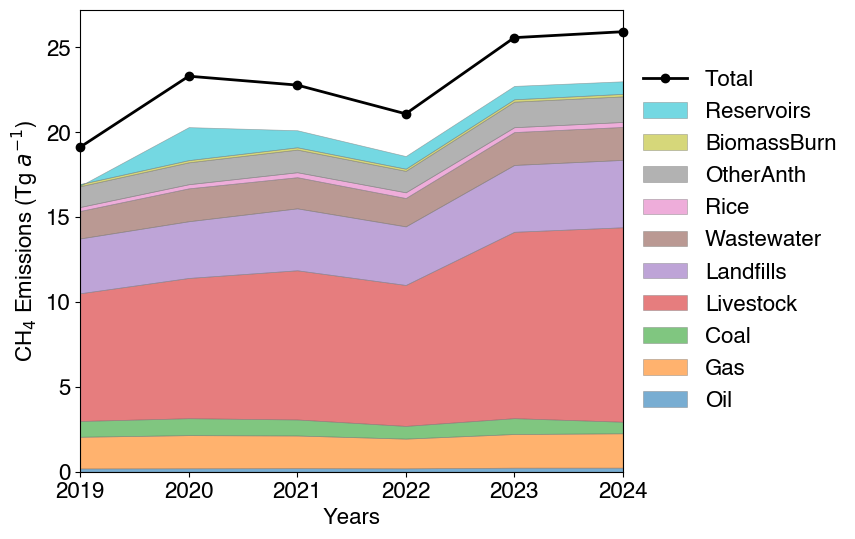

In [47]:
sectoral_attribution(years, mask_europe, europe_total)

           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  4.540237  3.265480  0.600729  20.504787   3.443128    6.281687   
2020  3.799247  3.442715  0.630492  23.970379   3.412400    6.908372   
2021  1.918348  2.876737  0.847092  24.788894   3.525857    6.792834   
2022  1.096157  2.506809  0.992792  24.439317   3.368799    6.464223   
2023  1.138381  3.168600  1.039683  26.894765   3.350233    6.889855   
2024  0.829787  3.207336  0.825596  28.418735   3.361717    6.931529   

          Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  1.572271   3.630734     5.238079    3.286507  
2020  1.664806   4.126675     5.735660    3.405434  
2021  1.578644   4.373043     6.538767    2.980950  
2022  1.349637   4.109723     6.172214    2.932413  
2023  1.439880   4.409360     6.464083    3.246774  
2024  1.717697   4.582046     6.585386    2.737416  


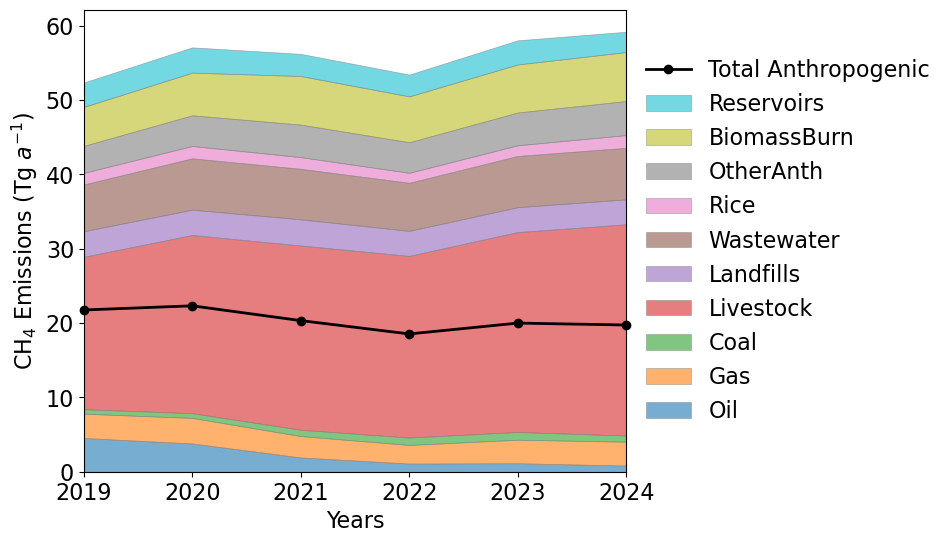

In [18]:
sectoral_attribution(years, mask_africa, africa_anthro)

           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  3.438907  1.853224  0.235078   3.265468   2.724670    3.002012   
2020  3.687974  2.086703  0.234220   3.459034   3.299474    3.398634   
2021  3.576218  2.325542  0.270921   4.113734   3.695119    3.799460   
2022  2.895622  2.237138  0.211532   3.628587   3.308828    3.533747   
2023  3.016786  2.370054  0.253772   4.061271   3.499873    3.794107   
2024  3.116091  2.328247  0.233115   3.924626   3.208869    3.646199   

          Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  0.208521   0.518525     0.012177    0.681348  
2020  0.185542   0.544099     0.014047    0.682817  
2021  0.157986   0.636591     0.018438    0.862079  
2022  0.179208   0.589812     0.016213    0.787419  
2023  0.177765   0.654626     0.017761    0.841086  
2024  0.151443   0.652689     0.016414    0.796681  


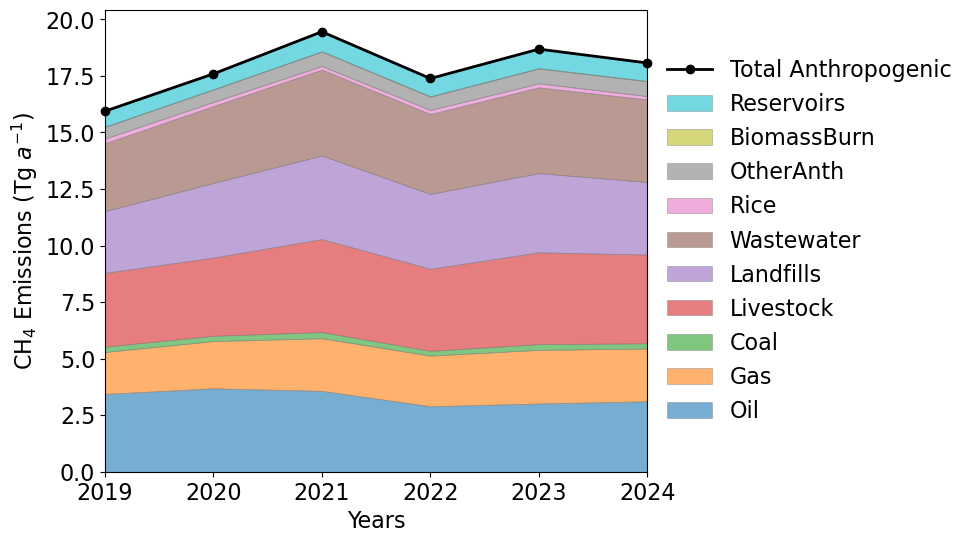

In [15]:
sectoral_attribution(years, mask_me, me_anthro)

           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  1.832763  4.415925  0.831764   4.308218   0.569988    0.629074   
2020  2.306329  5.029116  0.624680   4.639515   0.550794    0.680844   
2021  2.754221  5.373628  0.965771   5.571278   0.671393    0.861010   
2022  2.563218  4.035869  0.513886   4.805411   0.526859    0.717096   
2023  2.532057  4.218754  0.538428   4.873411   0.533248    0.691209   
2024  2.496682  4.080290  0.685562   4.970162   0.513107    0.670399   

          Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  0.045065   0.212659     0.146551    0.426491  
2020  0.050631   0.203567     0.141249    0.313533  
2021  0.078568   0.246079     0.175262    0.422284  
2022  0.098997   0.209334     0.164833    0.312236  
2023  0.096933   0.205296     0.177843    0.304783  
2024  0.126938   0.204386     0.204219    0.283903  


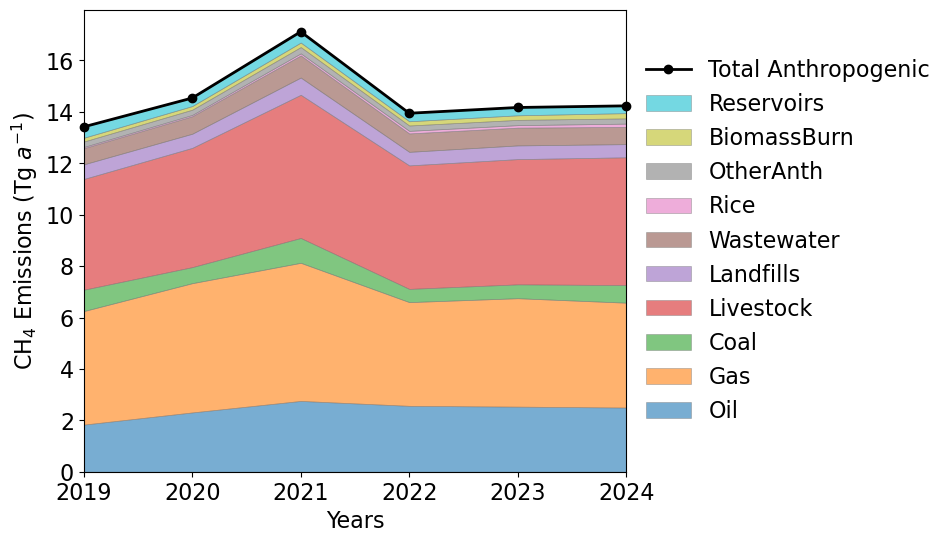

In [44]:
sectoral_attribution(years, mask_central_asia, central_asia_anthro)

           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  4.194660  0.348804  0.393884  21.872020   3.706837    5.115534   
2020  4.031025  0.258411  0.551541  24.008820   3.744562    5.206702   
2021  5.999248  0.319048  0.796223  26.123419   4.137205    5.515075   
2022  6.856571  0.316375  0.921088  27.898019   4.223874    5.899590   
2023  5.062969  0.265189  0.976197  27.185895   4.043202    5.644099   
2024  6.522183  0.333589  0.676906  29.699850   4.090997    5.855992   

          Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  1.344478   0.886072     3.146331    4.670499  
2020  0.831142   0.916958     3.466332    5.484688  
2021  0.859919   0.995099     3.207437    6.763257  
2022  0.805696   1.051012     3.720395    7.783983  
2023  0.800099   1.020922     3.451509    6.440698  
2024  0.926232   1.107354     3.857258    7.081028  


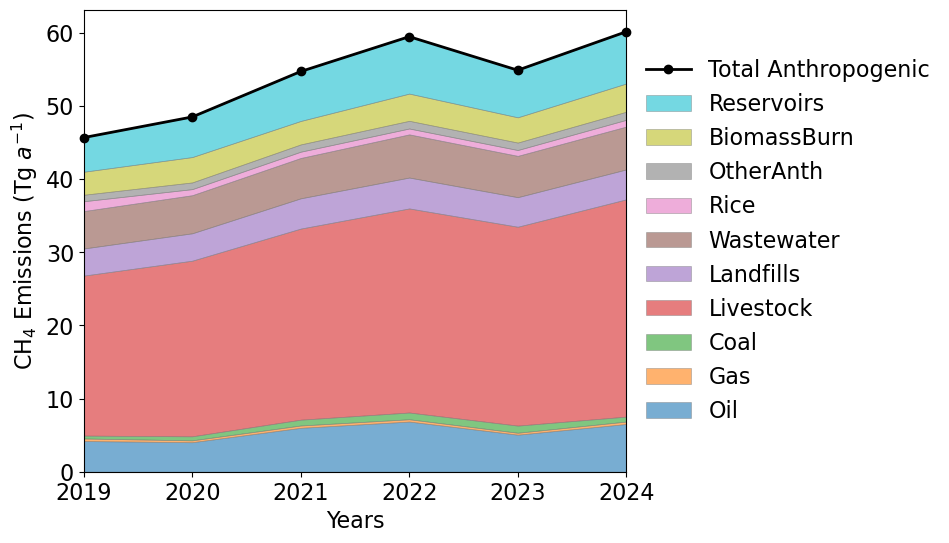

In [45]:
sectoral_attribution(years, mask_SA, SA_anthro)

           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  1.274528  1.360403 -0.296610   1.546312   1.092906    0.491674   
2020  1.487644  1.565074 -0.402188   1.716407   1.339622    0.600483   
2021  1.200281  1.456285  0.398772   1.726267   1.224651    0.549483   
2022  0.615442  1.281932  0.337710   1.715609   0.883367    0.399176   
2023  0.178170  1.221155  0.329882   1.647678   0.950686    0.428776   
2024 -0.516571  1.417713  0.307807   1.776059   1.435387    0.635213   

          Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  0.097173   0.162012     2.100801    0.521443  
2020  0.168798   0.194438     2.193008    0.424139  
2021  0.213871   0.189684     2.096855   -1.037033  
2022  0.266202   0.169800     1.951102   -2.576605  
2023  0.303591   0.165376     1.963696   -2.181702  
2024  0.195393   0.207003     1.764784   -1.152491  


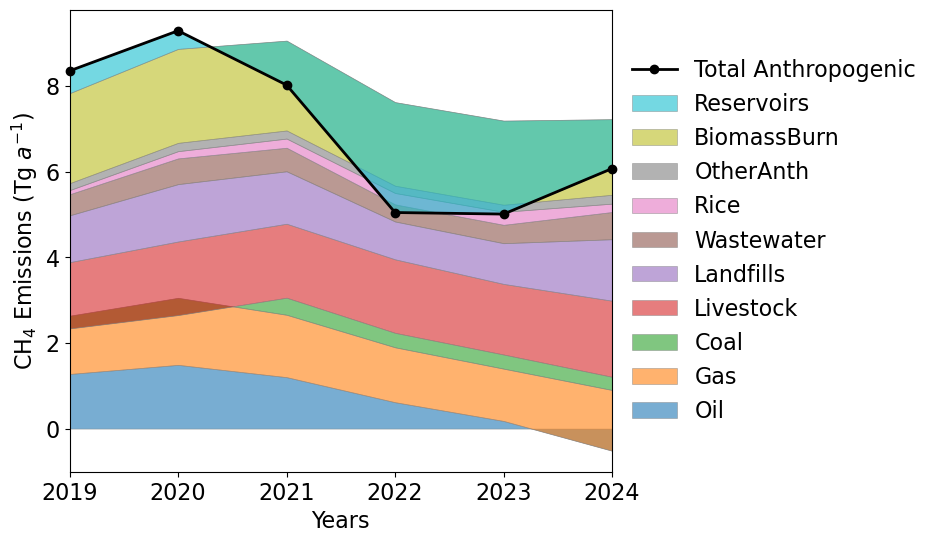

In [46]:
sectoral_attribution(years, mask_russia, russia_anthro)

           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  0.720716  0.063775  0.052117   0.704481   0.427666    0.031020   
2020  0.875592  0.072458  0.055517   0.778355   0.463466    0.034237   
2021  0.965171  0.064342  0.053257   0.790579   0.469856    0.033430   
2022  0.937011  0.065190  0.048341   0.744812   0.449083    0.032840   
2023  0.903452  0.056240  0.042884   0.697808   0.415825    0.029733   
2024  0.842506  0.090652  0.040802   0.711472   0.486435    0.037616   

              Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  7.593148e-08   0.044799     0.288885    0.722821  
2020  7.588160e-08   0.049317     0.470032    0.998150  
2021  9.083412e-08   0.049353     0.474818    1.208896  
2022  8.240094e-08   0.048520     0.472941    1.457745  
2023  3.538688e-08   0.043947     0.289898    1.806452  
2024  4.300525e-08   0.053508     0.309619    0.698648  


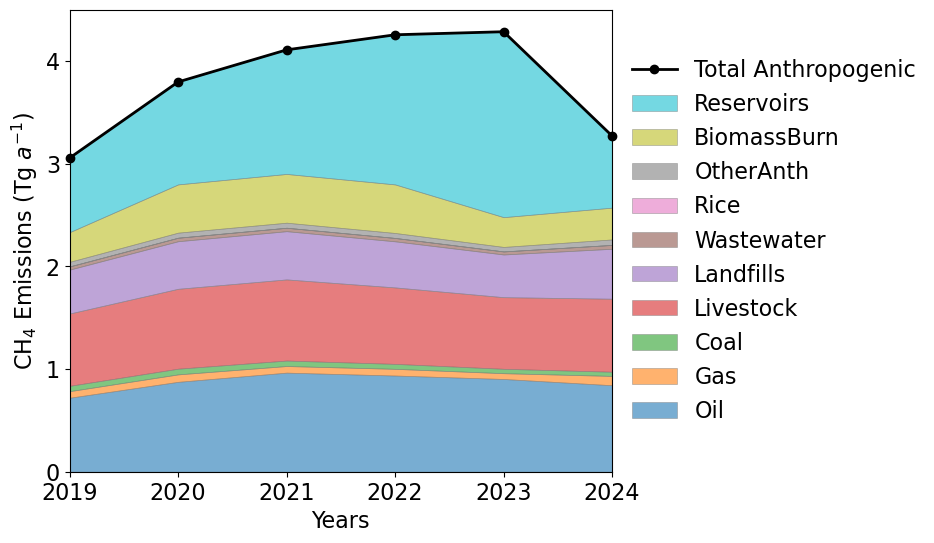

In [47]:
sectoral_attribution(years, mask_canada, canada_anthro)

           Oil       Gas      Coal  Livestock  Landfills  Wastewater  \
2019  2.310950  7.537668  3.011923   9.581845   4.541012    0.679252   
2020  1.688613  7.084037  3.550755   9.983120   4.484799    0.666151   
2021  1.880692  7.973289  3.865631  11.187414   4.950690    0.743377   
2022  1.981768  7.020707  2.852013  10.125482   4.436280    0.671895   
2023  2.164161  7.262666  2.894330  10.330852   4.334047    0.652795   
2024  1.959930  7.232023  3.290115  11.896051   4.773084    0.773111   

          Rice  OtherAnth  BiomassBurn  Reservoirs  
2019  0.218276   0.932082     0.104193    2.085282  
2020  0.150316   0.902546     0.102920    2.257116  
2021  0.133180   0.991917     0.111540    2.549920  
2022  0.128116   0.904749     0.097675    2.187096  
2023  0.116050   0.875539     0.095960    2.257010  
2024  0.131065   0.961615     0.107624    2.382943  


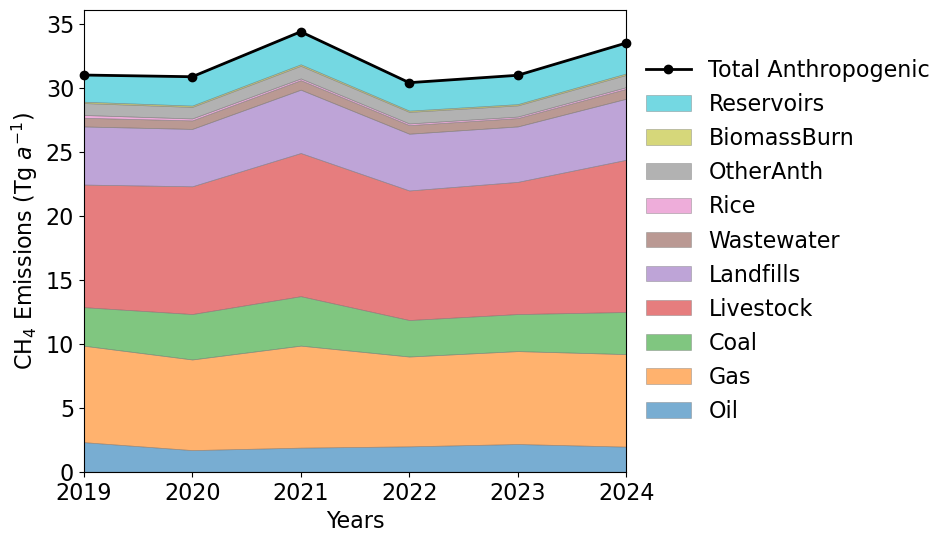

In [48]:
sectoral_attribution(years, mask_CONUS, CONUS_anthro)

### Posterior emissions map for every year

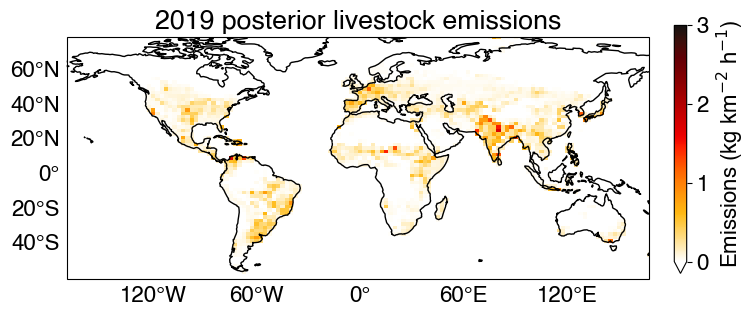

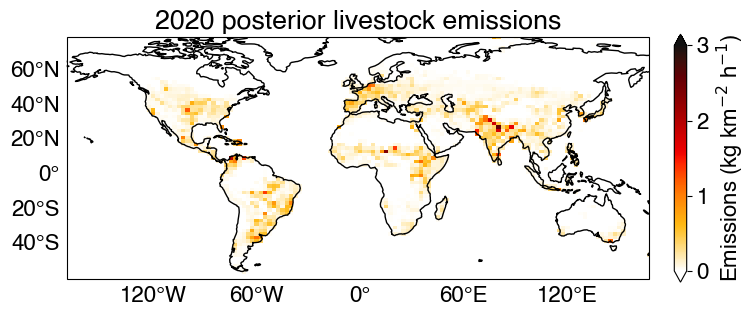

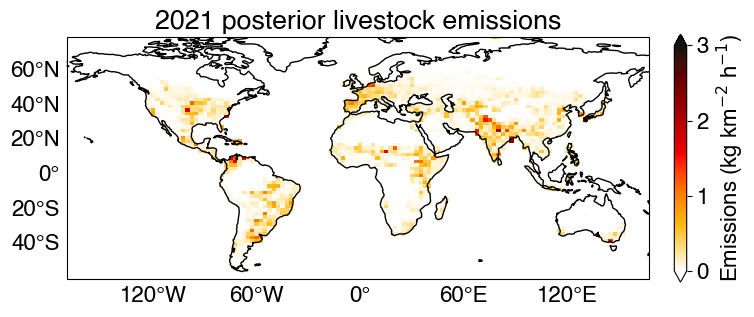

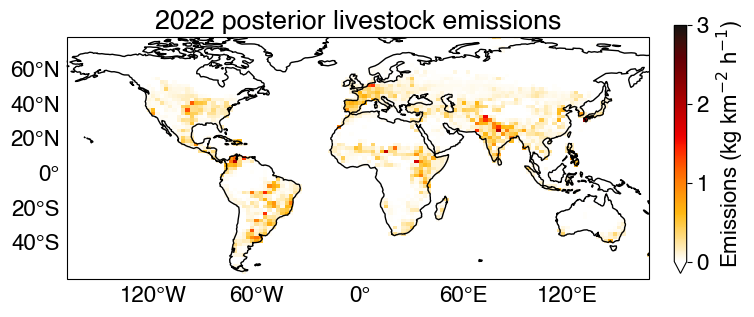

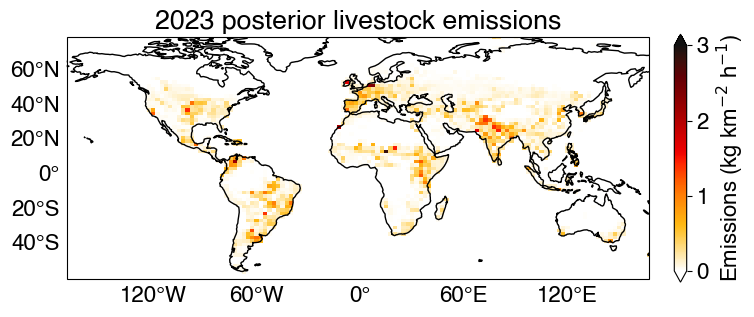

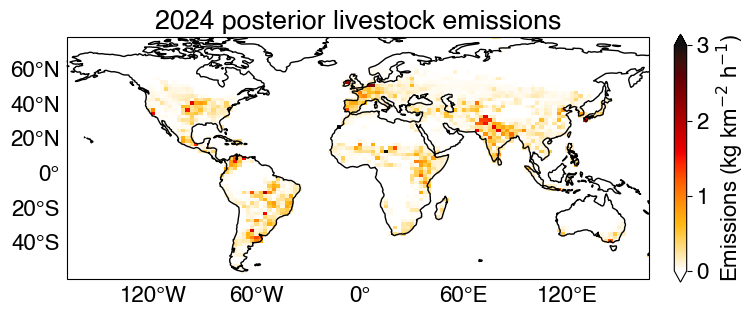

In [5]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
posterior_list = []

for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.open_dataset(path)
    posterior = posterior_ds['EmisCH4_Livestock']

    # Plot posterior emissions
    fig = plt.figure(figsize=(8, 8))
    plt.rcParams.update({"font.size": 16})
    ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

    posterior_kgkm2h = posterior * (1000**2) * 60 * 60  # Units kg/km2/h

    # plot_save_path="figures/posterior_emissions"

    plot_field(
        ax,
        posterior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=[-170, 167.5],
        lat_bounds=[-60, 80],
        vmin=0,
        vmax=3,
        title=f"{year} posterior livestock emissions",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=False,
        # save_path=plot_save_path
    )

### Posterior livestock 2021 - 2020

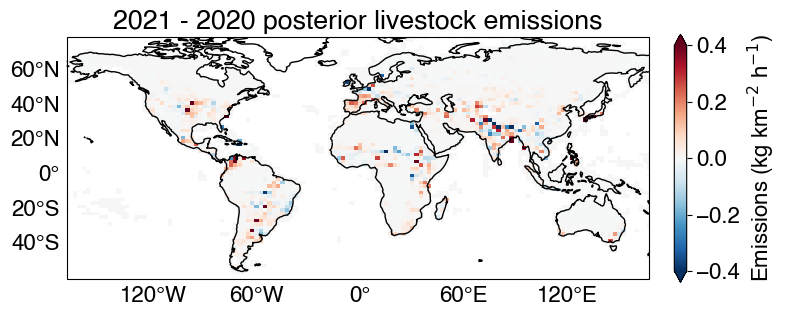

In [8]:
# set directory
path_2021 = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2021_annual/inversion/posterior_ds.nc'
path_2020 = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2020_annual/inversion/posterior_ds.nc'
posterior_ds_2021 = xr.open_dataset(path_2021)
posterior_2021 = posterior_ds_2021['EmisCH4_Livestock']
posterior_ds_2020 = xr.open_dataset(path_2020)
posterior_2020 = posterior_ds_2020['EmisCH4_Livestock']

# Plot posterior emissions
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

posterior_diff_kgkm2h = (posterior_2021 - posterior_2020) * (1000**2) * 60 * 60  # Units kg/km2/h

# plot_save_path="figures/posterior_emissions"

plot_field(
    ax,
    posterior_diff_kgkm2h,
    cmap='RdBu_r',
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=-0.4,
    vmax=0.4,
    title="2021 - 2020 posterior livestock emissions",
    cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=False,
    # save_path=plot_save_path
)

### Sectoral posterior emissions distribution for 2023

Plot saved to figures/posterior_sectoral/wetlands.png
Plot saved to figures/posterior_sectoral/oil&gas.png
Plot saved to figures/posterior_sectoral/coal.png
Plot saved to figures/posterior_sectoral/livestock.png
Plot saved to figures/posterior_sectoral/waste.png
Plot saved to figures/posterior_sectoral/rice.png
Plot saved to figures/posterior_sectoral/biomassburn.png
Plot saved to figures/posterior_sectoral/reservoirs.png


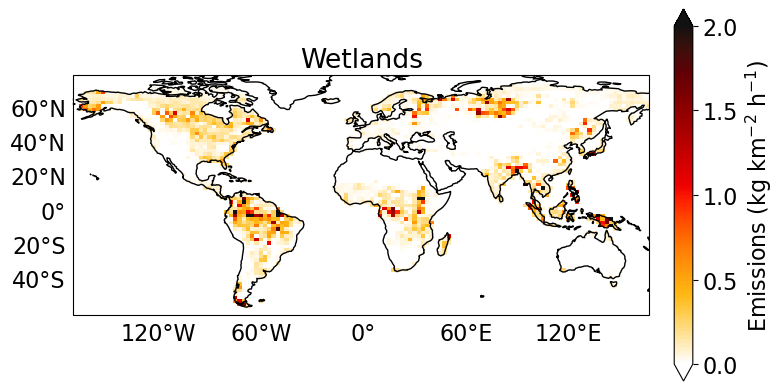

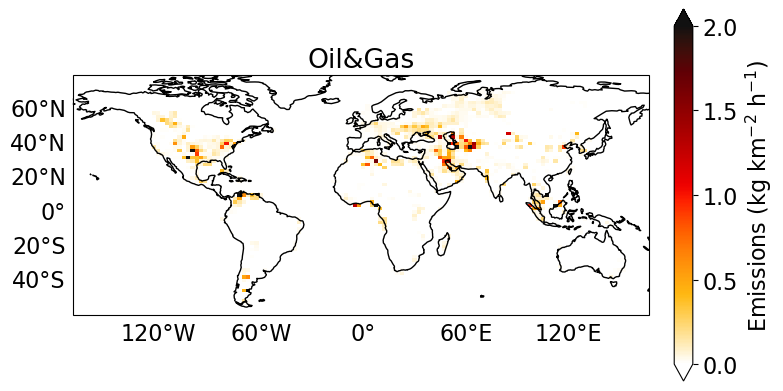

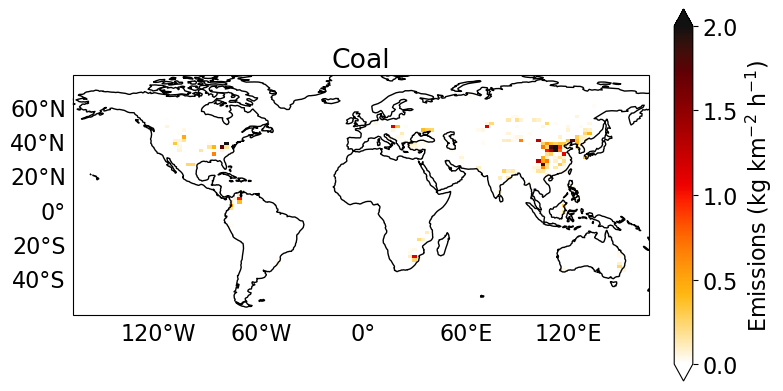

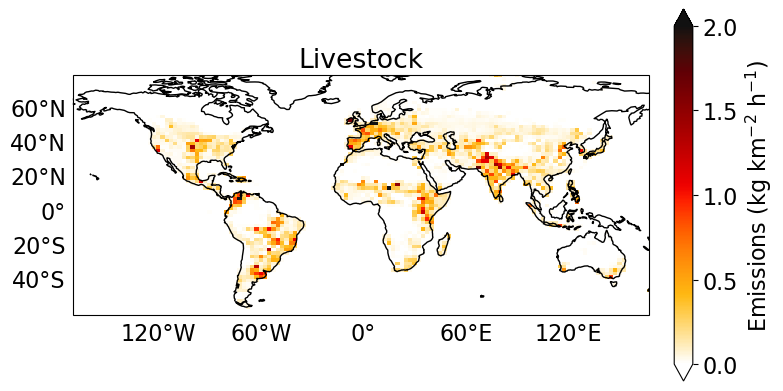

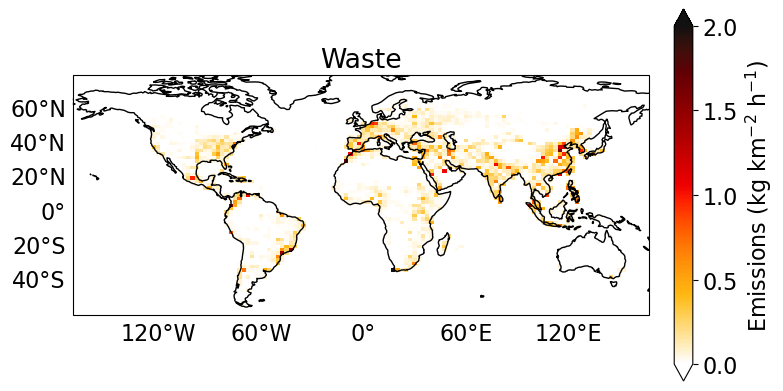

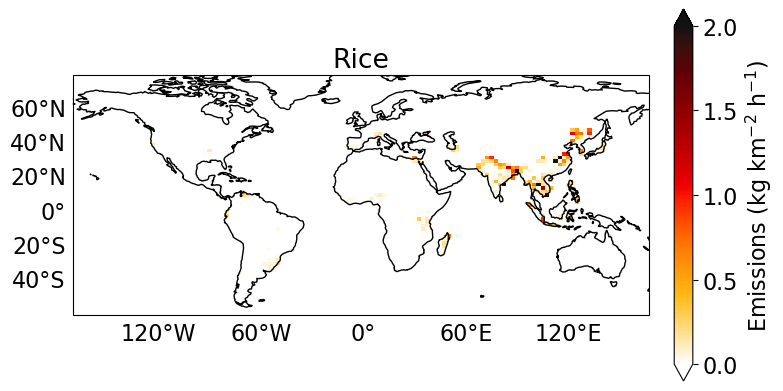

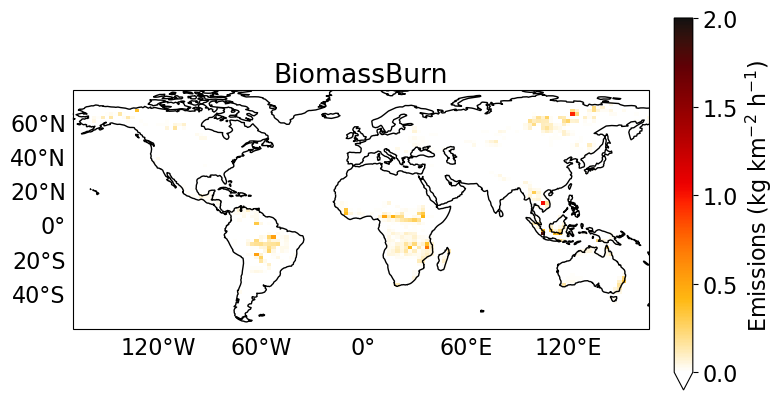

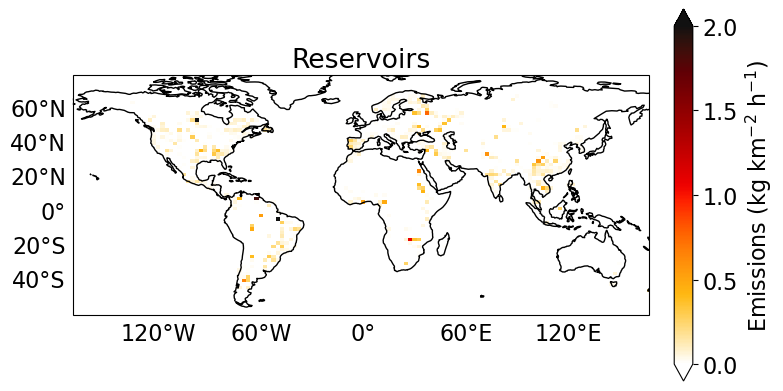

In [6]:
path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2023_annual/inversion/posterior_ds.nc'
posterior_ds = xr.open_dataset(path)

sectors = ["Wetlands",
           "Oil&Gas",
           "Coal",
           "Livestock",
           "Waste",
           "Rice",
           "BiomassBurn",
           "Reservoirs"]

for s in sectors:
    if s == "Oil&Gas":
        posterior_sectoral = posterior_ds['EmisCH4_Oil'] + posterior_ds['EmisCH4_Gas']
    elif s == "Waste":
        posterior_sectoral = posterior_ds['EmisCH4_Wastewater'] + posterior_ds['EmisCH4_Landfills']
    else:
        posterior_sectoral = posterior_ds[f'EmisCH4_{s}']


    # Plot posterior emissions
    fig = plt.figure(figsize=(8, 8))
    plt.rcParams.update({"font.size": 16})
    ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

    posterior_kgkm2h = posterior_sectoral * (1000**2) * 60 * 60  # Units kg/km2/h

    plot_save_path="figures/posterior_sectoral"

    plot_field(
        ax,
        posterior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=[-170, 167.5],
        lat_bounds=[-60, 80],
        vmin=0,
        vmax=2,
        title=f"{s}",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=False,
        save_path=plot_save_path
    )

### Average posterior emissions spatial map

Text(0.5, 1.0, '(a) Posterior surface fluxes (2019-2024 mean)')

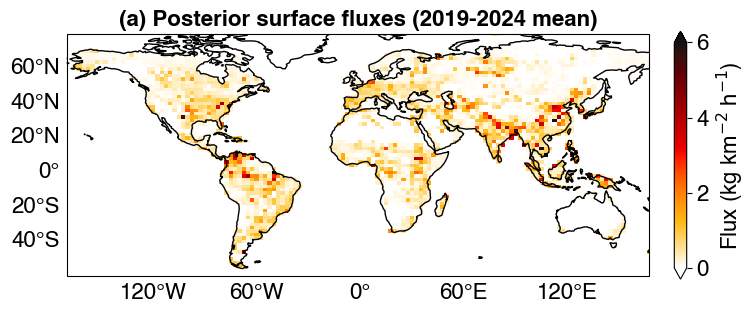

In [3]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
posterior_list = []
posterior_wetlands_list = []

for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.open_dataset(path)
    posterior = posterior_ds['EmisCH4_Total']
    posterior_wetlands = posterior_ds['EmisCH4_Wetlands']

    # Create year coordinate for stacking
    posterior = posterior.expand_dims({'year': [year]})
    posterior_wetlands = posterior_wetlands.expand_dims({'year': [year]})

    posterior_list.append(posterior)
    posterior_wetlands_list.append(posterior_wetlands)

# concatenate over all years
posterior_all_years = xr.concat(posterior_list, dim='year')
posterior_wetlands_all_years = xr.concat(posterior_wetlands_list, dim='year')

# Compute the mean
posterior_mean = posterior_all_years.mean(dim='year')
posterior_wetlands_mean = posterior_wetlands_all_years.mean(dim='year')

# Plot posterior emissions
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

posterior_kgkm2h = posterior_mean * (1000**2) * 60 * 60  # Units kg/km2/h

plot_field(
    ax,
    posterior_kgkm2h,
    cmap=cc.cm.linear_kryw_5_100_c67_r,
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=0,
    vmax=6,
    title="Posterior surface fluxes (2019-2024 mean)",
    cbar_label="Flux (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=False,
    # save_path=plot_save_path
)

plt.title("(a) Posterior surface fluxes (2019-2024 mean)", fontproperties=title_font, fontsize=16)

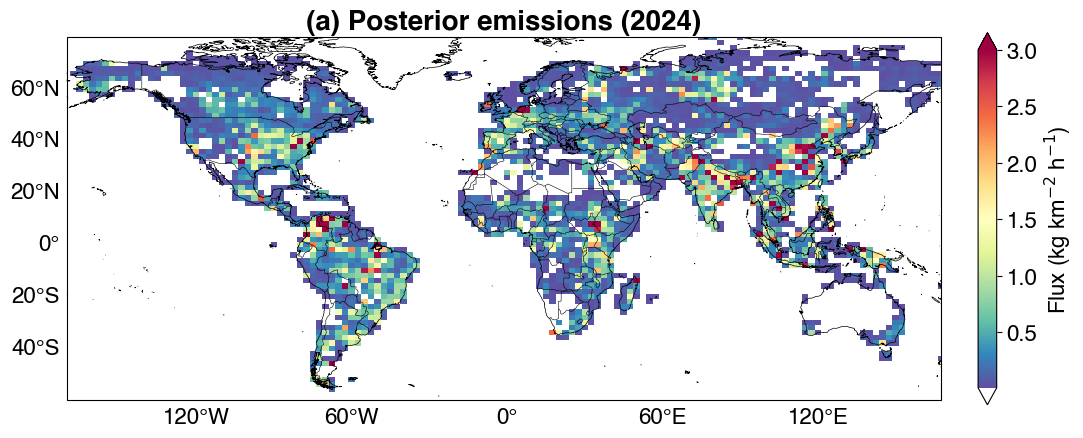

In [26]:
# Plot 2024 posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

posterior_2024 = posterior_all_years.sel(year=2024)
posterior_kgkm2h = posterior_2024 * (1000**2) * 60 * 60  # Units kg/km2/h

# set rainbow cmap
cmap = plt.cm.get_cmap('Spectral_r')
cmap.set_under('white')

plot_field(
    ax,
    posterior_kgkm2h,
    # cmap=cc.cm.linear_kryw_5_100_c67_r,
    cmap=cmap,
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=0.01,
    vmax=3,
    title="Posterior emissions (2024)",
    cbar_label="Flux (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True,
    # save_path=plot_save_path
)

plt.title("(a) Posterior emissions (2024)", fontproperties=title_font, fontsize=20)
# plt.savefig("figures/posterior_2024.png", dpi=600, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

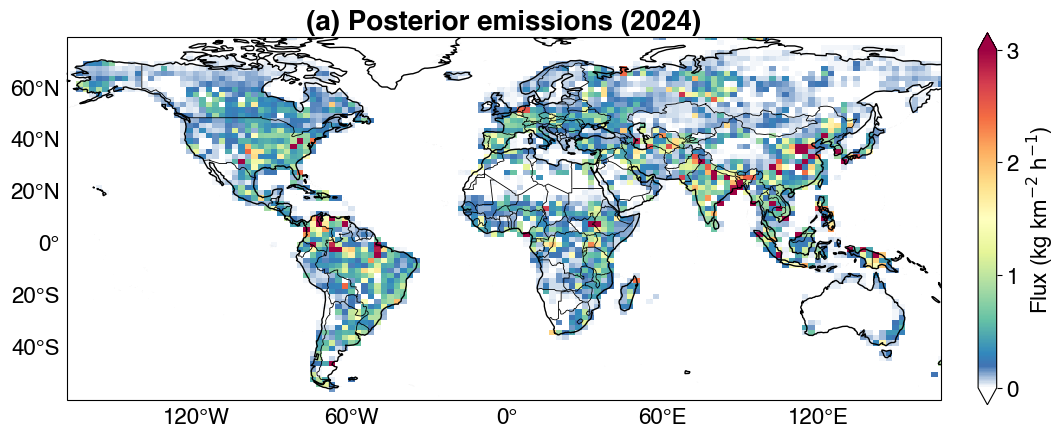

In [10]:
plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(12,12), subplot_kw={'projection': ccrs.PlateCarree()})

data_min = 0.0
data_cut = 0.2    # where you want “pure Spectral_r blue” to start
data_max = 3.0
fraction_cut = (data_cut - data_min) / (data_max - data_min)  

orig_cmap = plt.cm.get_cmap('Spectral_r')
blue_at_cut = orig_cmap(fraction_cut)
N = 256
i_cut = int(np.round(fraction_cut * (N - 1)))
white = np.array([1.0, 1.0, 1.0, 1.0])  # RGBA for pure white
target_blue = np.array(blue_at_cut)
if i_cut >= 1:
    whites_to_blue = np.linspace(white, target_blue, i_cut, axis=0)
else:
    # If fraction_cut is so tiny that i_cut == 0, skip this step.
    whites_to_blue = np.zeros((0, 4))
rest_of_colors = orig_cmap(np.linspace(fraction_cut, 1.0, N - i_cut))
new_colors = np.vstack([whites_to_blue, rest_of_colors])
cmap = LinearSegmentedColormap.from_list("Spectral_r_smooth_under", new_colors)
# cmap.set_under('white')
# norm = Normalize(vmin=0.01, vmax=3)

quadmesh = posterior_kgkm2h.plot.pcolormesh(
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=3,
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)

# posterior_kgkm2h.plot.pcolormesh(ax=ax,cmap=cmap, norm=norm, cbar_kwargs={"label": 'Flux (kg km$^{-2}$ h$^{-1}$)', "fraction": 0.02, "pad": 0.04}, transform=ccrs.PlateCarree())

extent = [-170, 167.5, -60, 80]
ax.set_extent(extent, crs=ccrs.PlateCarree())
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
ax.coastlines(color='black')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0)
gl.right_labels = False
gl.top_labels = False

# custom colorbar
cbar = plt.colorbar(
    quadmesh,            
    ax=ax,
    extend='both',         
    fraction=0.02,
    pad=0.04,
    label='Flux (kg km$^{-2}$ h$^{-1}$)'
)

# force tick at 0
ticks = [0, 1, 2, 3]
cbar.set_ticks(ticks)


plt.title("(a) Posterior emissions (2024)", fontproperties=title_font, fontsize=20)
plt.savefig("figures/posterior_2024.png", dpi=1200, bbox_inches="tight")
plt.show()

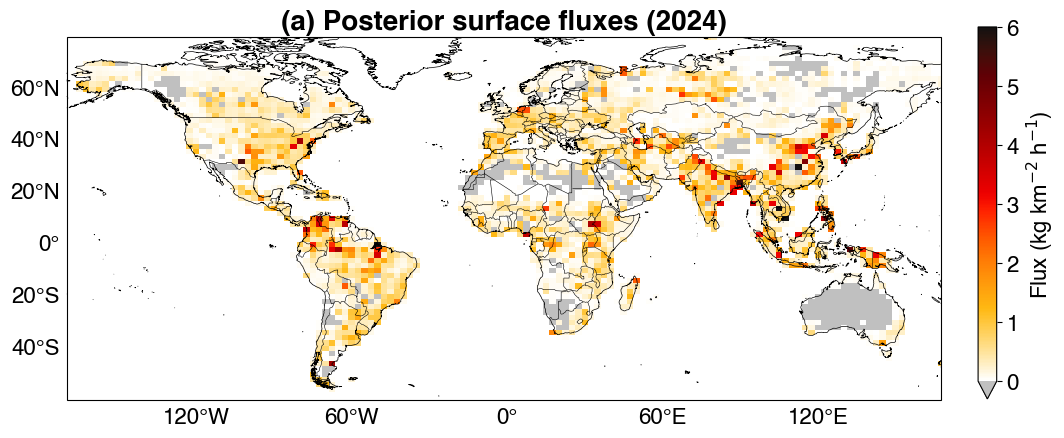

In [8]:
# pos = posterior_kgkm2h.where(posterior_kgkm2h >= 0)
# neg = posterior_kgkm2h.where(posterior_kgkm2h < 0)

cmap = cc.cm.linear_kryw_5_100_c67_r.copy()
cmap.set_under('silver')

fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax,
    posterior_kgkm2h,
    cmap=cmap,
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=0,
    vmax=6,
    extend='min',
    title="Posterior surface fluxes (2024)",
    cbar_label="Flux (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True,
)

plt.title("(a) Posterior surface fluxes (2024)", fontproperties=title_font, fontsize=20)
plt.show()

### Plot posterior wetlands 2019-2024 mean - prior 2019 wetlands

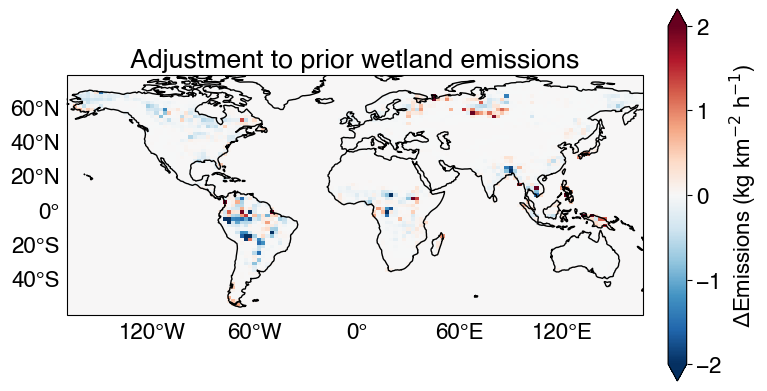

In [ ]:
# Load LPJ 2019 prior
lpj_prior_wetlands_2019 = xr.open_dataset('/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2019_annual_ResMefix/inversion/prior_ds.nc')['EmisCH4_Wetlands']

# Plot posterior wetland emissions mean
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# set the NaNs to white
cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad('white', alpha=0)
# make background color slightly grey to match the 0's
norm = mcolors.Normalize(vmin=-2, vmax=2)
central_color = cmap(norm(0))
ax.set_facecolor(central_color)

posterior_wetlands_kgkm2h = posterior_wetlands_mean * (1000**2) * 60 * 60  # Units kg/km2/h
prior_wetlands_kgkm2h = lpj_prior_wetlands_2019 * (1000**2) * 60 * 60  # Units kg/km2/h
diff_post_prior_wetlands = posterior_wetlands_kgkm2h - prior_wetlands_kgkm2h

plot_field(
    ax,
    diff_post_prior_wetlands,
    cmap='RdBu_r',
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=-2,
    vmax=2,
    title="Adjustment to prior wetland emissions",
    cbar_label="ΔEmissions (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=False,
    # save_path=plot_save_path
)

### Calc mean posterior / 2019 orig prior

In [26]:
prior_orig_2019 = xr.open_dataset("/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2019_annual_ResMefix/inversion/prior_ds.nc")["EmisCH4_Total"]

posterior_prior_scale = posterior_kgkm2h / (prior_orig_2019 * (1000**2) * 60 * 60)
posterior_prior_scale = posterior_prior_scale.where(prior_orig_2019 != 0)

posterior_prior_diff = (posterior_mean - prior_orig_2019) * (1000**2) * 60 * 60  # Units kg/km2/h

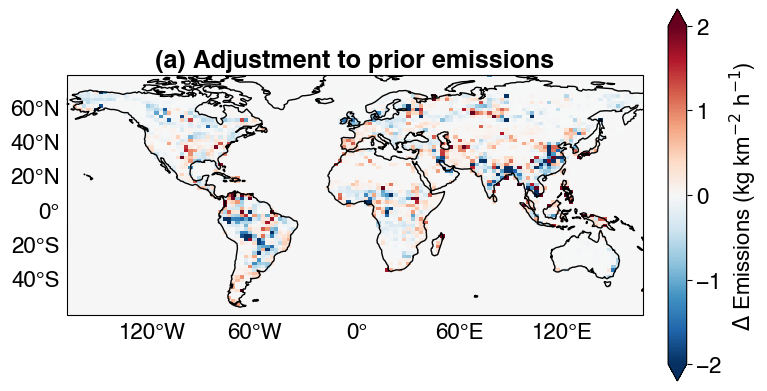

In [31]:
# Plot diff
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

# set the NaNs to white
cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad('white', alpha=0)
# make background color slightly grey to match the 0's
norm = mcolors.Normalize(vmin=-2, vmax=2)
central_color = cmap(norm(0))
ax.set_facecolor(central_color)

plot_field(
    ax,
    posterior_prior_diff,
    cmap='RdBu_r',
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=-2,
    vmax=2,
    title="Adjustment to prior emissions",
    cbar_label=r"$\Delta$ Emissions (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=False,
    # save_path=plot_save_path
)

plt.title('(a) Adjustment to prior emissions', fontproperties=title_font, fontsize=18)
plt.show()

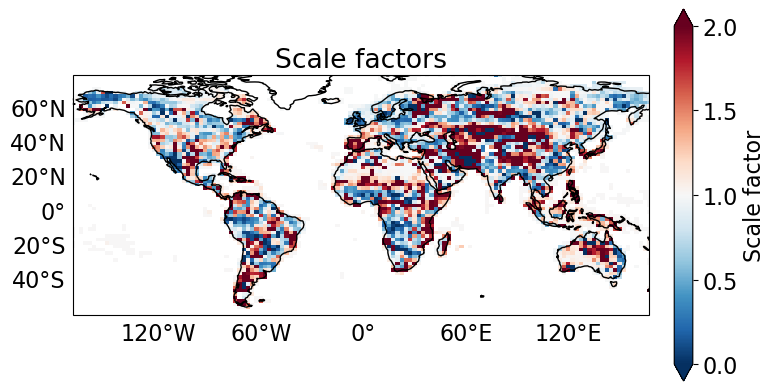

In [56]:
# Plot avg SF
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax,
    posterior_prior_scale,
    cmap='RdBu_r',
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=0,
    vmax=2,
    title="Scale factors",
    cbar_label="Scale factor",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=False,
    # save_path=plot_save_path
)

In [57]:
print(posterior_prior_scale.min().values, posterior_prior_scale.mean().values, posterior_prior_scale.max().values)

-178.71126266598992 1.0918031907994459 161.36055711928012


### Calculate average avkers

In [27]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
avkern_list = []

for year in years:
    # set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/gridded_posterior.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/gridded_posterior.nc'
    A_grid = xr.open_dataset(path)["A"]
    avkern_ROI = A_grid.where(state_vector_labels <= last_ROI_element)
    avkern_list.append(avkern_ROI)

# Calc average
avg = sum(avkern_list) / (len(years)-1)

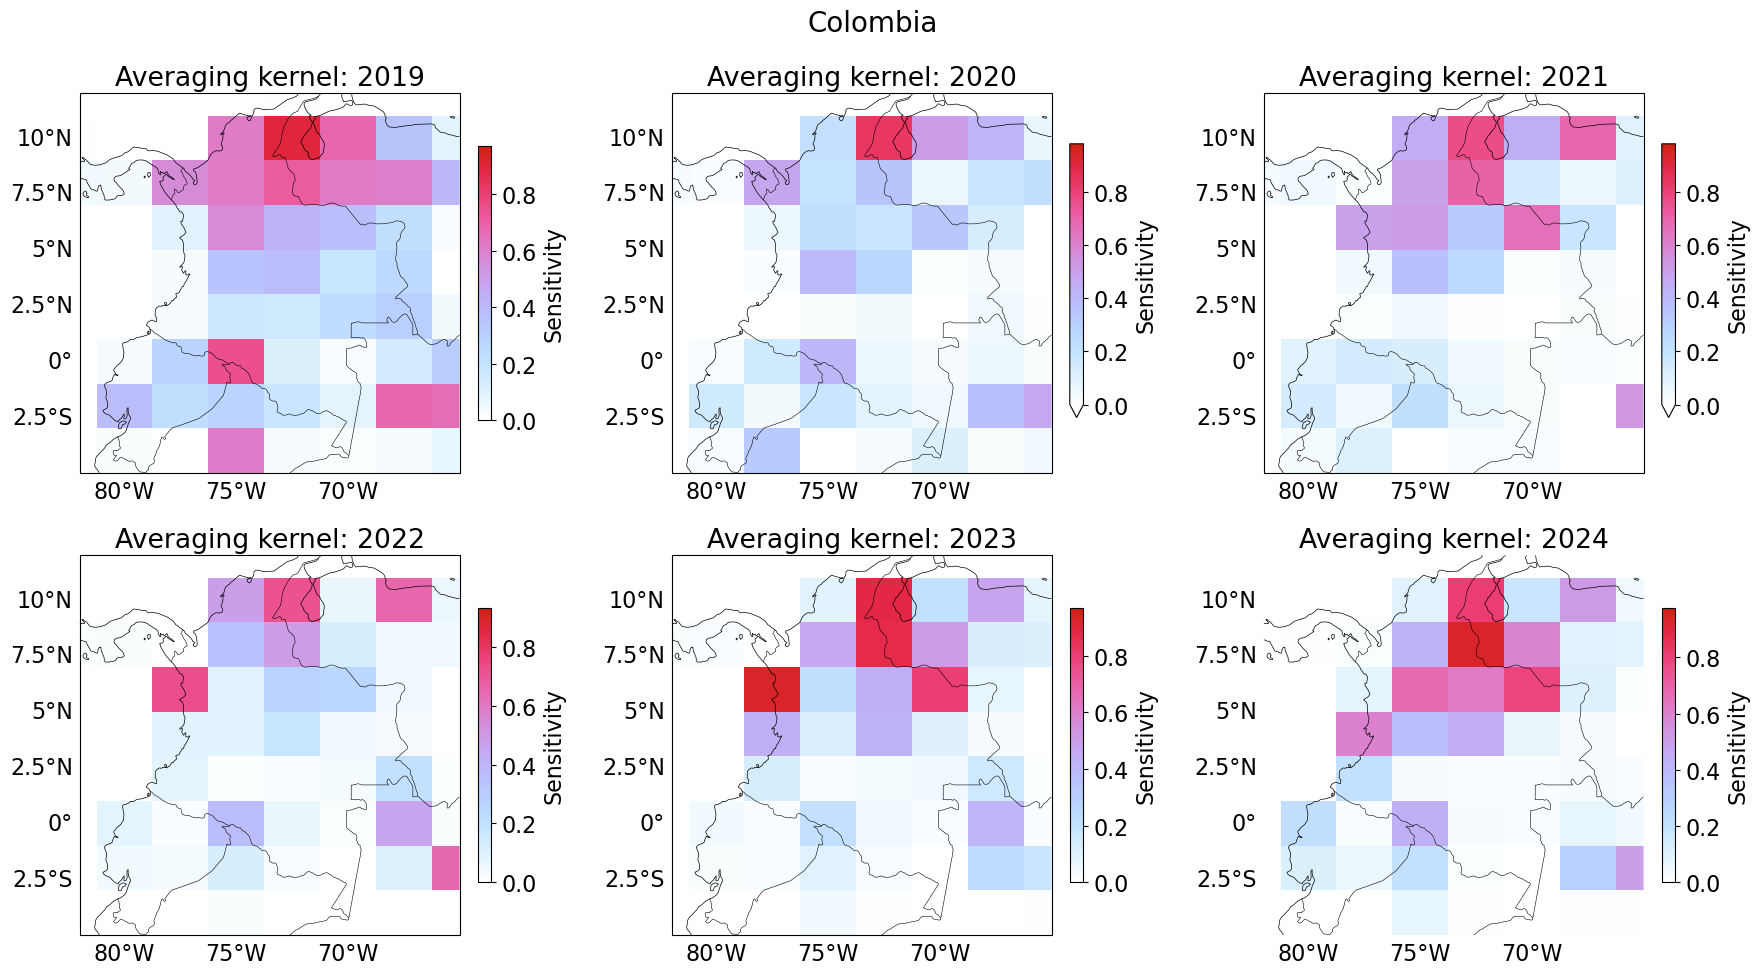

In [59]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={"projection": ccrs.PlateCarree()})
# add title
fig.suptitle("Colombia", fontsize=20)
plt.rcParams.update({"font.size": 16})

axs = axs.flatten()

# plot each year
for i, (year, avkern_ROI) in enumerate(zip(years, avkern_list)):
    ax = axs[i]
    plot_field(
        ax,
        avkern_ROI,
        cmap=cc.cm.CET_L19,
        lon_bounds=[-82, -65],
        lat_bounds=[-5, 12],
        vmin=0,
        title=f"Averaging kernel: {year}",
        cbar_label="Sensitivity",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=True,
        save_path=None
    )

# Turn off the unused subplot
axs[-1].axis("off")

plt.tight_layout()
plt.show()

In [60]:
mask_colombia = xr.open_dataset('~/integrated_methane_inversion/shapefiles/masks/colombia.nc')
mask_colombia = mask_colombia.rename({'__xarray_dataarray_variable__': 'Mask'})
# loop through avkern_list and open each avkern_ROI
print('Colombia averaging kernel sensitivities')
for i, (year, avkern_ROI) in enumerate(zip(years, avkern_list)):
    a_colombia = avkern_ROI.where(mask_colombia['Mask']).sum().values
    print(f'{year}: {a_colombia}')

Colombia averaging kernel sensitivities
2019: 23.20102238808291
2020: 13.576769267084531
2021: 15.002769807323768
2022: 10.677406454286215
2023: 11.56492135009477
2024: 13.070371418864568


In [4]:
print('Total averaging kernel sensitivities')
for i, (year, avkern_ROI) in enumerate(zip(years, avkern_list)):
    dofs = avkern_ROI.sum().values
    print(f'{year}: {dofs}')

Total averaging kernel sensitivities
2019: 388.46144181144575
2020: 345.8927265789927
2021: 426.08995828422275
2022: 255.86481389850485
2023: 295.2455625278144
2024: 287.83943771180185


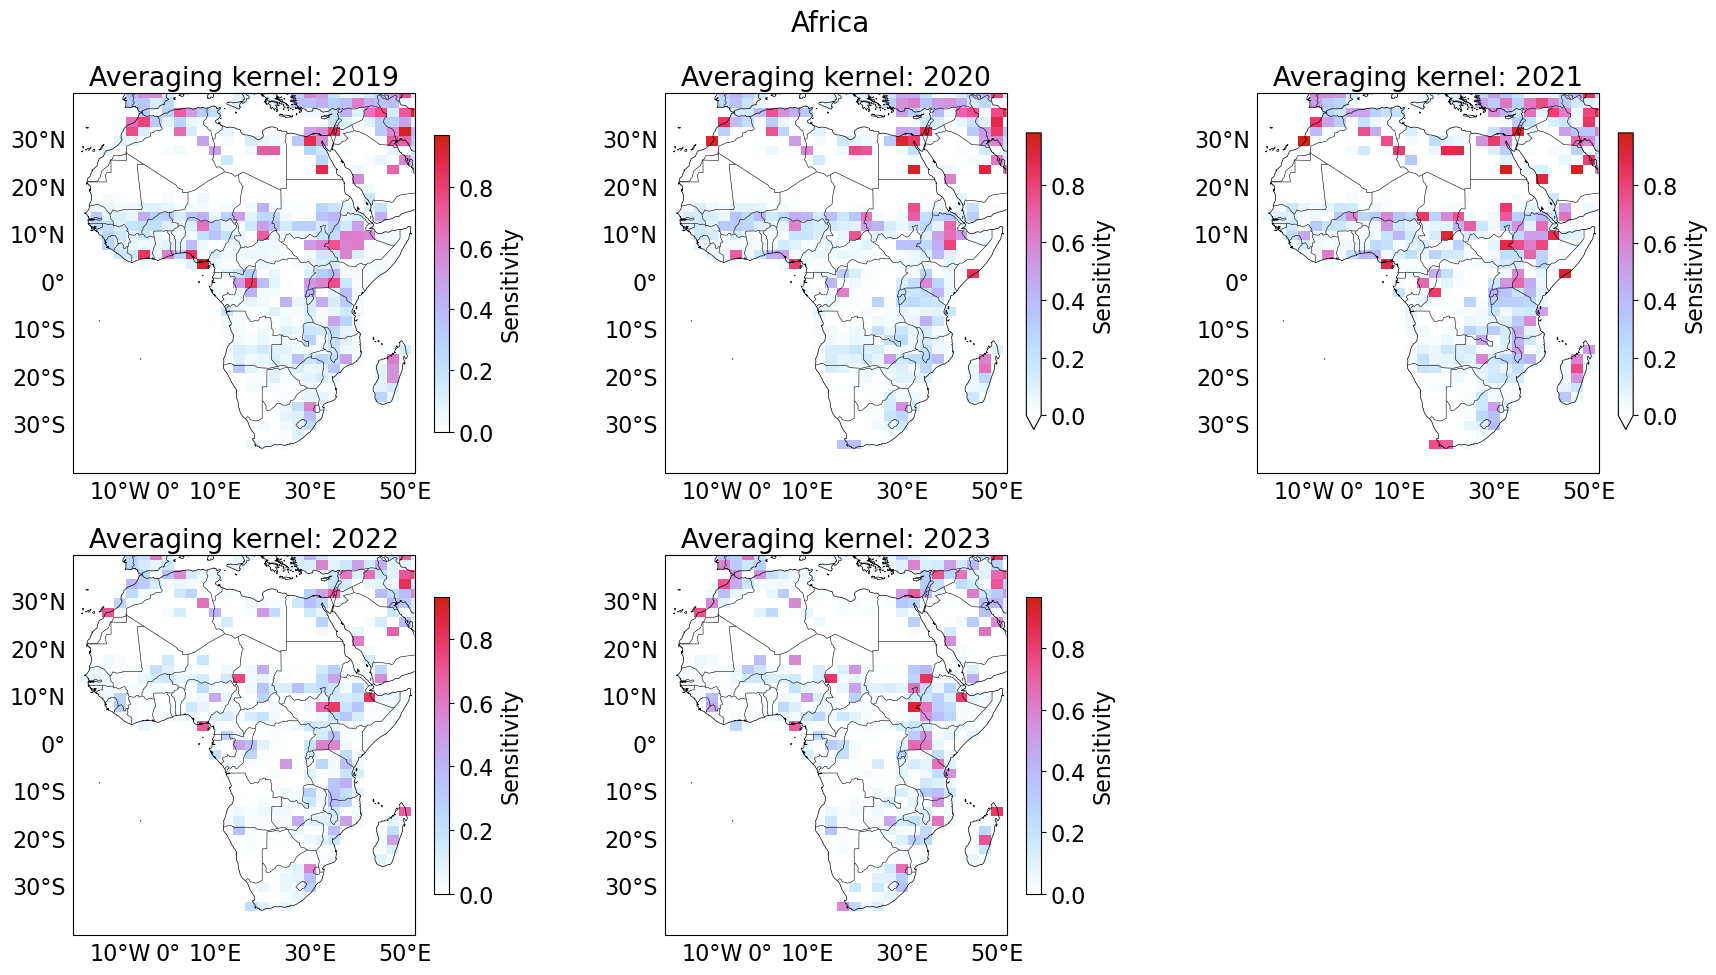

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={"projection": ccrs.PlateCarree()})
# add title
fig.suptitle("Africa", fontsize=20)
plt.rcParams.update({"font.size": 16})

axs = axs.flatten()

# plot each year
for i, (year, avkern_ROI) in enumerate(zip(years, avkern_list)):
    ax = axs[i]
    plot_field(
        ax,
        avkern_ROI,
        cmap=cc.cm.CET_L19,
        lon_bounds=[-20,52],
        lat_bounds=[-40,40],
        vmin=0,
        title=f"Averaging kernel: {year}",
        cbar_label="Sensitivity",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
        is_regional=True,
        save_path=None
    )

# Turn off the unused subplot
axs[-1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
mask_africa = xr.open_dataset('~/integrated_methane_inversion/shapefiles/masks/africa.nc')
mask_africa = mask_africa.rename({'__xarray_dataarray_variable__': 'Mask'})
# loop through avkern_list and open each avkern_ROI
print('Africa averaging kernel sensitivities')
for i, (year, avkern_ROI) in enumerate(zip(years, avkern_list)):
    a_africa = avkern_ROI.where(mask_africa['Mask']).sum().values
    print(f'{year}: {a_africa}')

Africa averaging kernel sensitivities
2019: 102.64715358290523
2020: 95.51890309023774
2021: 117.19554463708349
2022: 65.95797944455586
2023: 77.14418175852018


DOFS:  287.25197023270465


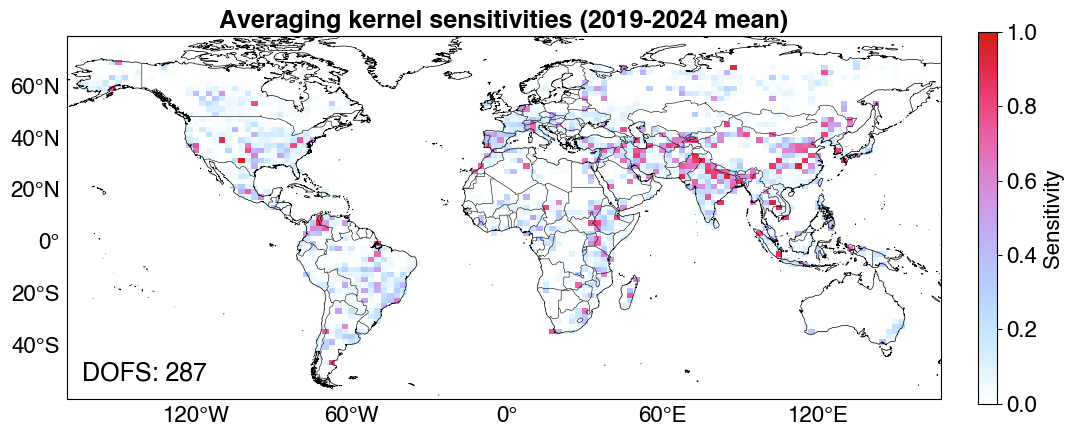

In [29]:
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

print('DOFS: ', avkern_ROI.sum().values)

plot_field(
    ax,
    avkern_ROI,
    cmap=cc.cm.CET_L19,
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmax=1,
    vmin=avkern_ROI.min(),
    title="Averaging kernel sensitivities (2019-2024 mean)",
    cbar_label="Sensitivity",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True,
    # save_path=plot_save_path
)

# plot text on graph
ax.text(-140, -50, "DOFS: 287", fontsize=18, color='black', ha='center', va='center')

plt.title('Averaging kernel sensitivities (2019-2024 mean)', fontproperties=title_font, fontsize=18)
plt.show()

## Latitudinal biases

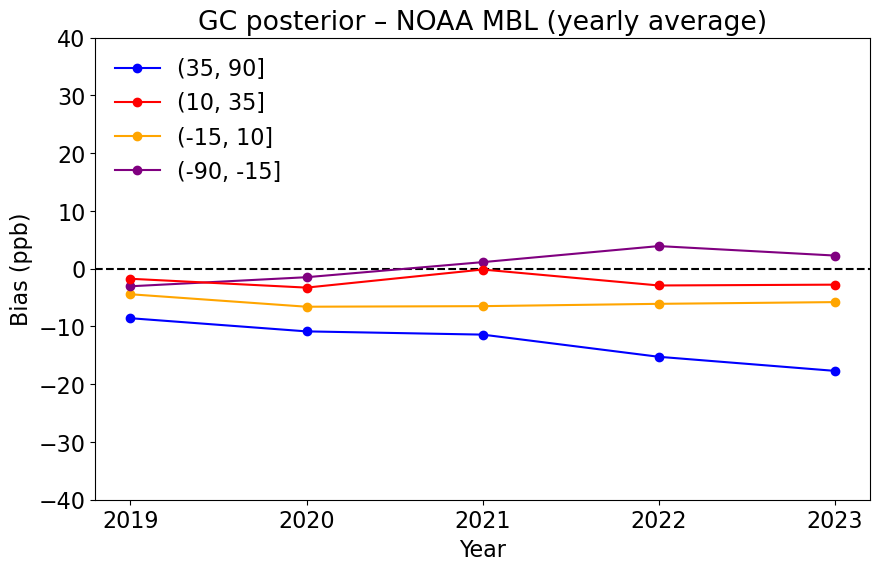

In [21]:
dfs = {
    2019: pd.DataFrame({'latitude': ['(-90, -15]', '(-15, 10]', '(10, 35]', '(35, 90]'],
                        'gcminusop': [-3.04, -4.42, -1.74, -8.57]}),
    2020: pd.DataFrame({'latitude': ['(-90, -15]', '(-15, 10]', '(10, 35]', '(35, 90]'],
                        'gcminusop': [-1.47, -6.58, -3.27, -10.85]}),
    2021: pd.DataFrame({'latitude': ['(-90, -15]', '(-15, 10]', '(10, 35]', '(35, 90]'],
                        'gcminusop': [1.14, -6.48, -0.14, -11.41]}),
    2022: pd.DataFrame({'latitude': ['(-90, -15]', '(-15, 10]', '(10, 35]', '(35, 90]'],
                        'gcminusop': [3.92, -6.08, -2.90, -15.25]}),
    2023: pd.DataFrame({'latitude': ['(-90, -15]', '(-15, 10]', '(10, 35]', '(35, 90]'],
                        'gcminusop': [2.28, -5.78, -2.76, -17.69]})
}

# add year column
for year, lat_df in dfs.items():
    lat_df['year'] = year

# Concatenate
lat_df_all = pd.concat(dfs.values(), ignore_index=True)

# pivot the dataframe so each latitude band is a column
lat_df_all = lat_df_all.pivot(index='year', columns='latitude', values='gcminusop')

# Plot
cmap = {
    '(-90, -15]': 'purple',
    '(-15, 10]': 'orange',
    '(10, 35]': 'red',
    '(35, 90]': 'blue'
}
legend_order = ['(35, 90]', '(10, 35]', '(-15, 10]', '(-90, -15]']
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
plt.rcParams.update({"font.size": 16})

plt.axhline(y=0, color='black', linestyle='--') # add 0 line

handles_dict = {}

for lat_band in lat_df_all.columns:
    line, = plt.plot(lat_df_all.index, lat_df_all[lat_band], marker='o', label=lat_band, color=cmap[lat_band])
    handles_dict[lat_band] = line

plt.xlabel('Year')
plt.ylabel('Bias (ppb)')
plt.xticks(lat_df_all.index.astype(int)) # plot years on x axis
plt.ylim(-40, 40)
plt.title('GC posterior – NOAA MBL (yearly average)')
handles = [handles_dict[lat] for lat in legend_order]
labels = legend_order
ax.legend(handles, labels, frameon=False, loc='upper left')
plt.show()


### Differences in individual years

Plot saved to posterior_emissions_diff/2023_$-$_2022_emissions.png


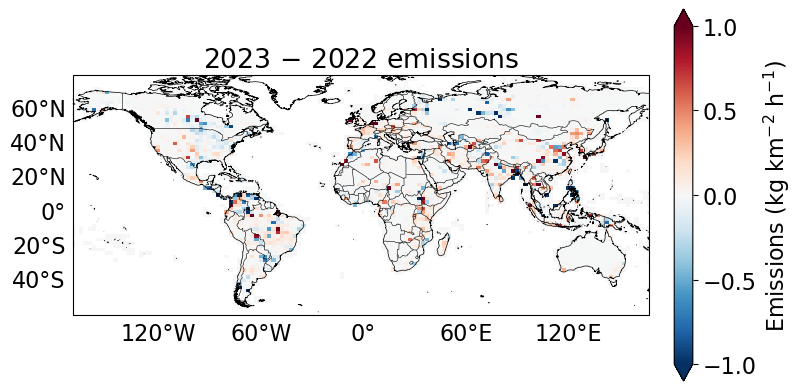

In [23]:
year = 2023

path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
previous_path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year-1}_annual/inversion/posterior_ds.nc'

posterior_ds = xr.load_dataset(path)
posterior = posterior_ds["EmisCH4_Total"]
posterior_ds_prev = xr.load_dataset(previous_path)
posterior_prev = posterior_ds_prev["EmisCH4_Total"]

diff = (posterior - posterior_prev) * (1000**2) * 60 * 60  # Units kg/km2/h

# Plot difference
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_save_path="posterior_emissions_diff"

plot_field(
    ax,
    diff,
    cmap='RdBu_r',
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=-1,
    vmax=1,
    title=f"{year} $-$ {year-1} emissions",
    cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True,
    save_path=plot_save_path
)

### Differences in individual years versus original prior

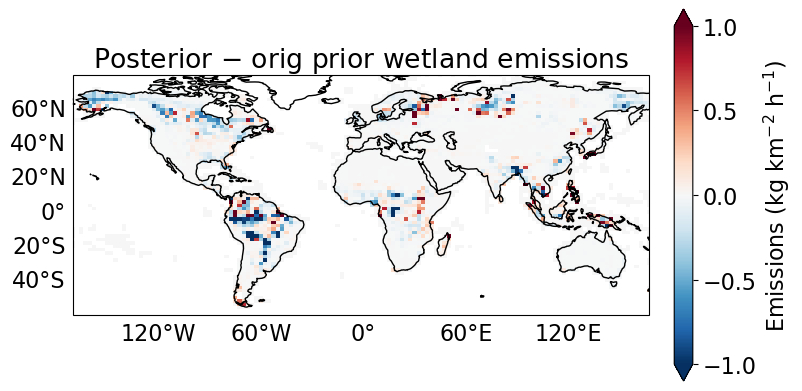

In [6]:
year = 2023

path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
orig_path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/prior_ds_orig.nc'

posterior_ds = xr.load_dataset(path)
posterior = posterior_ds["EmisCH4_Wetlands"]
prior_ds_orig = xr.load_dataset(orig_path)
prior_orig = prior_ds_orig["EmisCH4_Wetlands"]

diff = (posterior - prior_orig) * (1000**2) * 60 * 60  # Units kg/km2/h

# Plot difference
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax,
    diff,
    cmap='RdBu_r',
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=-1,
    vmax=1,
    title=f"Posterior $-$ orig prior wetland emissions",
    cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=False,
    # save_path=plot_save_path
)